# Análisis exploratorio de los datasets: FNSPID vs. FinMultiTime y inferencia con FinBERT

## Autor: Eloi Serantes Abal

### Librerías necesarias

In [ ]:
!pip install pandas_market_calendars -q
!pip install transformers torch tqdm

In [ ]:
import pandas as pd
import zipfile
import os
from huggingface_hub import hf_hub_download
from datasets import load_dataset
import pandas_market_calendars as mcal
import json
import warnings

import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from google.colab import drive
import os

# Librerías BERT
import torch
from transformers import pipeline
from tqdm.auto import tqdm

import requests
import time

import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

drive.mount('/content/drive')

# Ignoramos warnings para mantener la consola limpia
warnings.filterwarnings('ignore')

## FinMultiTime

Prueba rápida para observar unas pequeñas muestras del dataset

In [ ]:
def obtener_noticias_ticker(ticker="AAPL"):
    dataset_id = "Wenyan0110/Multimodal-Dataset-Image_Text_Table_TimeSeries-for-Financial-Time-Series-Forecasting"
    archivo_zip = "text/sp500_news.zip"

    print(f"--- Iniciando proceso para {ticker} ---")

    try:
        # Descarga
        print("Accediendo al dataset en Hugging Face...")
        path_local = hf_hub_download(repo_id=dataset_id, filename=archivo_zip, repo_type="dataset")

        # Abrir el ZIP y buscar el archivo específico
        with zipfile.ZipFile(path_local, 'r') as z:
            nombres = z.namelist()
            archivo_interno = next((n for n in nombres if f"{ticker}.jsonl".lower() in n.lower()), None)

            if not archivo_interno:
                print(f"No se encontró el archivo para {ticker} dentro del ZIP.")
                return None

            print(f"Leyendo: {archivo_interno}")
            with z.open(archivo_interno) as f:
                df = pd.read_json(f, lines=True)
                df = df.rename(columns={
                    'Date': 'fecha',
                    'Article_title': 'titulo',
                    'Article': 'contenido',
                    'Stock_symbol': 'ticker',
                    'Url': 'url'
                })

                # Convertir fecha y verificar si hay horas reales
                df['fecha'] = pd.to_datetime(df['fecha'])
                horas_reales = df[df['fecha'].dt.time != pd.to_datetime('00:00:00').time()]

                print(f"Se han cargado {len(df)} noticias.")
                if horas_reales.empty:
                    print("Nota: Todas las noticias tienen la hora fijada en 00:00:00 (solo fecha disponible).")
                else:
                    print(f"Se detectaron {len(horas_reales)} noticias con precisión de hora.")

                return df

    except Exception as e:
        print(f"Error: {e}")
        return None

df_aapl = obtener_noticias_ticker("AAPL")
if df_aapl is not None:
    pd.set_option('display.max_colwidth', 150)
    print("\n--- VISTA PREVIA DE LAS ÚLTIMAS 5 FILAS ---")
    print(df_aapl[['fecha', 'titulo', 'contenido']].tail(5))

--- Iniciando proceso para AAPL ---
Accediendo al dataset en Hugging Face...
Leyendo: sp500_news/AAPL.jsonl
Se han cargado 9311 noticias.
Nota: Todas las noticias tienen la hora fijada en 00:00:00 (solo fecha disponible).

--- VISTA PREVIA DE LAS ÚLTIMAS 5 FILAS ---
          fecha  \
9306 2022-06-03   
9307 2022-06-03   
9308 2022-06-03   
9309 2022-06-03   
9310 2022-06-03   

                                                                                                           titulo  \
9306  After Hours Most Active for Jun 3, 2022 : MNDT, TSM, PM, QQQ, INVA, CERN, INTC, AAPL, ERJ, COTY, INFY, PLTR   
9307                     US STOCKS-Wall St ends down with strong jobs data keeping the pressure on for rate hikes   
9308                                                           4 Top Stock Trades for Monday: SPY, AAPL, LULU, MU   
9309                                                                  Apple Was the Worst Stock in the Dow Friday   
9310                             

## **PROBLEMA**
- No tiene la hora de la publicación de las noticias.
- Posible solución: sumarle un día a cada noticia para así salvarnos de posibles noticias que fueron publicadas después del cierre de mercado.

# FNSPID

- Visualización rápida de una pequeñas muestras del dataset para comprobar campos.

In [ ]:
# Cargar el dataset con streaming para ir rápido
ds = load_dataset("Zihan1004/FNSPID", split="train", streaming=True)

print("Buscando noticias de AAPL con timestamp preciso...")

data = []
for i, row in enumerate(ds):
    if row['Stock_symbol'] == 'AAPL':
        data.append(row)
    if len(data) >= 500:
        break

df = pd.DataFrame(data)

# Convertir Fecha a datetime y pasar a hora de Nueva York
df['Date'] = pd.to_datetime(df['Date'])
df['Date_NY'] = df['Date'].dt.tz_convert('America/New_York')

def calcular_fecha_trading(row):
    dt = row['Date_NY']
    # Si la noticia es después de las 16:00, afecta al día siguiente
    if dt.hour >= 16:
        impacto = dt.date() + pd.Timedelta(days=1)
    else:
        impacto = dt.date()

    # Si el impacto cae en fin de semana, mover al lunes
    if impacto.weekday() == 5: # Sábado
        impacto += pd.Timedelta(days=2)
    elif impacto.weekday() == 6: # Domingo
        impacto += pd.Timedelta(days=1)

    return impacto

# Aplicar lógica de impacto
df['Trading_Date'] = df.apply(calcular_fecha_trading, axis=1)

# Visualización
print("\n--- ANÁLISIS DE IMPACTO TEMPORAL (AAPL) ---")
cols_ver = ['Date_NY', 'Trading_Date', 'Article_title']
print(df[cols_ver].head(10))

Repo card metadata block was not found. Setting CardData to empty.


Buscando noticias de AAPL con timestamp preciso...

--- ANÁLISIS DE IMPACTO TEMPORAL (AAPL) ---
                    Date_NY Trading_Date  \
0 2020-06-10 03:33:26-04:00   2020-06-10   
1 2020-06-10 00:14:08-04:00   2020-06-10   
2 2020-06-09 23:53:47-04:00   2020-06-10   
3 2020-06-09 23:19:25-04:00   2020-06-10   
4 2020-06-09 22:27:11-04:00   2020-06-10   
5 2020-06-09 16:52:01-04:00   2020-06-10   
6 2020-06-09 07:14:07-04:00   2020-06-09   
7 2020-06-09 05:58:46-04:00   2020-06-09   
8 2020-06-09 04:41:02-04:00   2020-06-09   
9 2020-06-09 03:11:34-04:00   2020-06-09   

                                                                                                                                           Article_title  
0                                                                                  Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed  
1                                                                                                          10

In [ ]:
def obtener_datos_crudos(ticker="AAPL", num_noticias=10):
    print(f"Conectando con FNSPID para extraer noticias de {ticker}...")

    ds = load_dataset("Zihan1004/FNSPID", split="train", streaming=True)
    noticias = []

    for row in ds:
        if row['Stock_symbol'] == ticker:
            noticias.append(row)
        if len(noticias) >= num_noticias:
            break

    df_raw = pd.DataFrame(noticias)

    print("\n" + "="*60)
    print(f"DATOS EN CRUDO (RAW) - MUESTRA DE {ticker.upper()}")
    print("="*60)
    print(df_raw[['Date', 'Stock_symbol', 'Article_title']].head(10))
    print("-" * 60)

    primer_articulo = df_raw['Article'].iloc[0]
    texto_muestra = primer_articulo[:80] if primer_articulo else "[Sin contenido en el cuerpo del artículo]"

    print(f"Ejemplo de fecha original: {df_raw['Date'].iloc[0]}")
    print(f"Ejemplo de texto: {texto_muestra}...")
    print("="*60 + "\n")

    return df_raw

df_raw = obtener_datos_crudos("AAPL", 15)

Conectando con FNSPID para extraer noticias de AAPL...


Repo card metadata block was not found. Setting CardData to empty.



DATOS EN CRUDO (RAW) - MUESTRA DE AAPL
                      Date Stock_symbol  \
0  2020-06-10 07:33:26 UTC         AAPL   
1  2020-06-10 04:14:08 UTC         AAPL   
2  2020-06-10 03:53:47 UTC         AAPL   
3  2020-06-10 03:19:25 UTC         AAPL   
4  2020-06-10 02:27:11 UTC         AAPL   
5  2020-06-09 20:52:01 UTC         AAPL   
6  2020-06-09 11:14:07 UTC         AAPL   
7  2020-06-09 09:58:46 UTC         AAPL   
8  2020-06-09 08:41:02 UTC         AAPL   
9  2020-06-09 07:11:34 UTC         AAPL   

                                                                                                                                           Article_title  
0                                                                                  Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed  
1                                                                                                          10 Biggest Price Target Changes For Wednesday  
2                    

### Preprocesado inicial de prueba
- Ajuste de la Franja Horaria: Originalmente esta en UTC cuando en New York se encuentra en otra zona horaria.
- Configuración de Calendario para la Bolsa de Nueva York: Determinamos el horario de la bolsa, así como los festivos que cuenta. Tambien, se crea una columna en la cual se indica si afecta al precio del cierre del día o a la apertura del día siguiente.
- Limpieza de Texto.

In [ ]:
def preprocesar_datos_financieros(df_input):
    if df_input is None or df_input.empty:
        print("No hay datos para procesar.")
        return None

    print("Iniciando preprocesamiento")
    df = df_input.copy()

    # Ajuste de Zona Horaria (UTC -> New York)
    df['Date'] = pd.to_datetime(df['Date'])
    df['Date_NY'] = df['Date'].dt.tz_convert('America/New_York')

    # Configuración de Calendario de la Bolsa (NYSE)
    nyse = mcal.get_calendar('NYSE')

    def calcular_impacto(row):
        dt = row['Date_NY']
        hora = dt.time()
        apertura = pd.Timestamp("09:30:00").time()
        cierre = pd.Timestamp("16:00:00").time()

        # Determinamos si el impacto es en Apertura (OPEN) o Cierre (CLOSE)
        if hora < apertura:
            impacto_inicial = dt.date()
            target = "OPEN"
        elif apertura <= hora < cierre:
            impacto_inicial = dt.date()
            target = "CLOSE"
        else:
            # Noticia After-hours: salta al día siguiente de mercado
            impacto_inicial = dt.date() + pd.Timedelta(days=1)
            target = "OPEN"

        # GESTIÓN DE FESTIVOS Y FINES DE SEMANA
        # Buscamos el siguiente día en que la bolsa abre
        schedule = nyse.schedule(start_date=impacto_inicial, end_date=impacto_inicial + pd.Timedelta(days=10))
        proximo_dia_valido = schedule.iloc[0].name.date()

        # Si la fecha original era festivo/finde, el impacto es siempre OPEN del día que abra
        if impacto_inicial != proximo_dia_valido:
            return proximo_dia_valido, "OPEN"
        return impacto_inicial, target

    print("Alineando con el calendario de NYSE y detectando targets (Open/Close)")
    resultados = df.apply(calcular_impacto, axis=1)
    df['Trading_Date'], df['Impact_Target'] = zip(*resultados)

    # Limpieza de Texto
    print("Normalizando texto...")
    df['Article_Clean'] = df['Article'].fillna("").astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    df = df.sort_values('Date_NY').reset_index(drop=True)
    print("\n" + "="*60)
    print("DATOS PROCESADOS (LISTOS PARA FORECASTING)")
    print("="*60)
    cols_vista = ['Date_NY', 'Trading_Date', 'Impact_Target', 'Article_title']
    print(df[cols_vista].head(10))
    print("="*60)

    return df

df_final = preprocesar_datos_financieros(df_raw)

Iniciando preprocesamiento profesional...
Alineando con el calendario de NYSE y detectando targets (Open/Close)...
Normalizando texto...

DATOS PROCESADOS (LISTOS PARA FORECASTING)
                    Date_NY Trading_Date Impact_Target  \
0 2020-06-01 20:00:00-04:00   2020-06-02          OPEN   
1 2020-06-01 20:00:00-04:00   2020-06-02          OPEN   
2 2020-06-01 20:00:00-04:00   2020-06-02          OPEN   
3 2020-06-01 20:00:00-04:00   2020-06-02          OPEN   
4 2020-06-01 20:00:00-04:00   2020-06-02          OPEN   
5 2020-06-09 03:11:34-04:00   2020-06-09          OPEN   
6 2020-06-09 04:41:02-04:00   2020-06-09          OPEN   
7 2020-06-09 05:58:46-04:00   2020-06-09          OPEN   
8 2020-06-09 07:14:07-04:00   2020-06-09          OPEN   
9 2020-06-09 16:52:01-04:00   2020-06-10          OPEN   

                                                                                                                                           Article_title  
0                        

- Visualización rápida para ver si existen noticias con la hora real.

In [ ]:
def preprocesar_datos_financieros_precisos(df_input):
    if df_input is None or df_input.empty:
        print("Error: No hay datos para procesar.")
        return None

    print("Iniciando preprocesamiento")
    df = df_input.copy()

    # Convertir a datetime y filtrar horas por defecto (00:00:00 UTC)
    df['Date'] = pd.to_datetime(df['Date'])

    total_antes = len(df)
    df = df[df['Date'].dt.time != pd.Timestamp("00:00:00").time()]
    total_despues = len(df)

    # Ajuste de Zona Horaria a Nueva York
    df['Date_NY'] = df['Date'].dt.tz_convert('America/New_York')

    # Configuración de Calendario NYSE
    nyse = mcal.get_calendar('NYSE')

    def calcular_impacto(row):
        dt = row['Date_NY']
        hora = dt.time()
        apertura = pd.Timestamp("09:30:00").time()
        cierre = pd.Timestamp("16:00:00").time()

        if hora < apertura:
            impacto_inicial = dt.date()
            target = "OPEN"
        elif apertura <= hora < cierre:
            impacto_inicial = dt.date()
            target = "CLOSE"
        else:
            impacto_inicial = dt.date() + pd.Timedelta(days=1)
            target = "OPEN"

        # Gestión de Festivos y Fines de Semana
        schedule = nyse.schedule(start_date=impacto_inicial, end_date=impacto_inicial + pd.Timedelta(days=10))
        proximo_dia_valido = schedule.iloc[0].name.date()

        if impacto_inicial != proximo_dia_valido:
            return proximo_dia_valido, "OPEN"
        return impacto_inicial, target

    resultados = df.apply(calcular_impacto, axis=1)
    df['Trading_Date'], df['Impact_Target'] = zip(*resultados)

    # Limpieza de Texto y Ordenamiento
    df['Article_Clean'] = df['Article'].fillna("").astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    df = df.sort_values('Date_NY').reset_index(drop=True)

    conteo_targets = df['Impact_Target'].value_counts()

    print("\n" + "-"*30)
    print("RESUMEN DE FILTRADO Y SESIONES")
    print("-"*30)
    print(f"Noticias originales: {total_antes}")
    print(f"Noticias eliminadas (sin hora): {total_antes - total_despues}")
    print(f"Noticias útiles finales: {total_despues}")
    print("-"*30)
    print("DISTRIBUCIÓN DE IMPACTO (TARGET):")
    for target, cantidad in conteo_targets.items():
        porcentaje = (cantidad / total_despues) * 100
        print(f"- {target}: {cantidad} noticias ({porcentaje:.1f}%)")
    print("-"*30 + "\n")

    return df

df_final = preprocesar_datos_financieros_precisos(df_raw)

def mostrar_noticias_finales(df):
    if df is not None and not df.empty:
        print("-" * 80)
        print("VISTA DETALLADA DE LAS NOTICIAS PREPROCESADAS")
        print("-" * 80)

        columnas_inspeccion = ['Date_NY', 'Trading_Date', 'Impact_Target', 'Article_title']
        print(df[columnas_inspeccion].head(15))

mostrar_noticias_finales(df_final)

Iniciando preprocesamiento de alta precisión...

------------------------------
RESUMEN DE FILTRADO Y SESIONES
------------------------------
Noticias originales: 15
Noticias eliminadas (sin hora): 5
Noticias útiles finales: 10
------------------------------
DISTRIBUCIÓN DE IMPACTO (TARGET):
- OPEN: 10 noticias (100.0%)
------------------------------

--------------------------------------------------------------------------------
VISTA DETALLADA DE LAS NOTICIAS PREPROCESADAS
--------------------------------------------------------------------------------
                    Date_NY Trading_Date Impact_Target  \
0 2020-06-09 03:11:34-04:00   2020-06-09          OPEN   
1 2020-06-09 04:41:02-04:00   2020-06-09          OPEN   
2 2020-06-09 05:58:46-04:00   2020-06-09          OPEN   
3 2020-06-09 07:14:07-04:00   2020-06-09          OPEN   
4 2020-06-09 16:52:01-04:00   2020-06-10          OPEN   
5 2020-06-09 22:27:11-04:00   2020-06-10          OPEN   
6 2020-06-09 23:19:25-04:00   20

- Visualización rápida para observar la calidad del texto y la longitud del mismo.

In [ ]:
def verificar_contenido_texto(ticker="AAPL", muestra=100):
    print(f"Analizando calidad del texto para {ticker}...")
    ds = load_dataset("Zihan1004/FNSPID", split="train", streaming=True)

    con_texto = []
    sin_texto = 0

    for row in ds:
        if row['Stock_symbol'] == ticker:
            # Verificamos si 'Article' existe y tiene cierta longitud
            if row['Article'] and len(row['Article'].split()) > 20:
                con_texto.append(row)
            else:
                sin_texto += 1

        if len(con_texto) >= muestra:
            break

    df = pd.DataFrame(con_texto)

    print(f"\n--- REPORTE DE CALIDAD ---")
    print(f"Noticias analizadas hasta encontrar {muestra} con contenido válido.")
    print(f"Noticias descartadas (vacías o muy cortas): {sin_texto}")
    print(f"Noticias válidas encontradas: {len(df)}")

    if not df.empty:
        print("\n--- EJEMPLO DE TEXTO COMPLETO (Columna 'Article') ---")
        print(df['Article'].iloc[0][:500] + "...")
        print("-" * 60)
        print("Título asociado:", df['Article_title'].iloc[0])

verificar_contenido_texto("AAPL", 15)

Analizando calidad del texto para AAPL...


Repo card metadata block was not found. Setting CardData to empty.



--- REPORTE DE CALIDAD ---
Noticias analizadas hasta encontrar 15 con contenido válido.
Noticias descartadas (vacías o muy cortas): 473
Noticias válidas encontradas: 15

--- EJEMPLO DE TEXTO COMPLETO (Columna 'Article') ---
After an absolute disaster of a year in 2022, the stock market appears to have turned the corner. Each of the major market indexes has gained more than 20% from their respective trough. Perhaps more importantly, the S&P 500 and the Nasdaq Composite are within striking distance of new highs, which will check the final box marking the start of a new bull market.
Closing out the old and ringing in the new is a great time for examination, and one of the places I start is with my portfolio. A review ...
------------------------------------------------------------
Título asociado: My 6 Largest Portfolio Holdings Heading Into 2024 -- and the Important Investing Lesson I Learned From Each One


# Análisis completo en ambos datasets

Se busca saber si cuentan con resúmenes, horas de los artículos, distribución temporal, etc.

In [ ]:
def imprimir_resultados(nombre, total, validas, defecto):
    invalidas = total - validas
    real = validas - defecto

    porc_val = (validas / total) * 100 if total > 0 else 0
    porc_inv = (invalidas / total) * 100 if total > 0 else 0
    porc_def = (defecto / validas) * 100 if validas > 0 else 0
    porc_real = (real / validas) * 100 if validas > 0 else 0

    print(f"\n{'='*50}")
    print(f"RESULTADOS FINALES: {nombre}")
    print(f"{'='*50}")
    print(f"Total de entradas analizadas: {total:,}")
    print(f"Entradas válidas:             {validas:,} ({porc_val:.2f}%)")
    print(f"Entradas nulas/inválidas:     {invalidas:,} ({porc_inv:.2f}%)")
    print("-" * 50)
    print("SOBRE LAS ENTRADAS VÁLIDAS:")
    print(f"Hora por defecto (00:00:00):  {defecto:,} entradas ({porc_def:.2f}%)")
    print(f"Hora real (detallada):        {real:,} entradas ({porc_real:.2f}%)\n")

In [ ]:
def analizar_noticias_fnspid():
    print("\n" + "*"*60)
    print("CONECTANDO CON ZIHAN1004/FNSPID")
    print("*"*60)

    total_entradas = 0
    entradas_validas = 0
    hora_defecto_abs = 0

    try:
        dataset = load_dataset("Zihan1004/FNSPID", data_files={"train": "Stock_news/**"}, split="train", streaming=True)
        iterator = iter(dataset.iter(batch_size=10000))

        while True:
            try:
                batch = next(iterator)
                df_batch = pd.DataFrame(batch)

                if total_entradas == 0:
                    print(f"--> Campos detectados: {df_batch.columns.tolist()}")

                total_entradas += len(df_batch)

                fechas = pd.to_datetime(df_batch['Date'], errors='coerce', utc=True)
                validas_mask = fechas.notna()
                entradas_validas += validas_mask.sum()

                fechas_validas = fechas[validas_mask]
                es_defecto = (fechas_validas.dt.hour == 0) & (fechas_validas.dt.minute == 0) & (fechas_validas.dt.second == 0)
                hora_defecto_abs += es_defecto.sum()

                if total_entradas % 500000 == 0:
                    print(f"  Procesadas {total_entradas:,} noticias...")

            except StopIteration:
                break
            except Exception as batch_error:
                print(f"\n[!] Corte de red de Hugging Face detectado tras {total_entradas:,} registros.")
                print(f"El análisis se detiene aquí y se imprimirán los resultados hasta el corte.")
                break

    except Exception as e:
        print(f"Error crítico al iniciar FNSPID: {e}")

    imprimir_resultados("Zihan1004/FNSPID", total_entradas, entradas_validas, hora_defecto_abs)

In [ ]:
def analizar_noticias_finmultitime():
    print("*"*60)
    print("CONECTANDO CON WENYAN0110 (Corrección de nombre de archivo)")
    print("*"*60)

    repo_id = "Wenyan0110/Multimodal-Dataset-Image_Text_Table_TimeSeries-for-Financial-Time-Series-Forecasting"
    archivo_correcto = "text/sp500_news.zip"

    total_entradas = 0
    entradas_validas = 0
    hora_defecto_abs = 0
    campos_mostrados = False

    candidatos_fecha = ['Date', 'date', 'Datetime', 'time', 'publish_date', 'timestamp', 'release_date']

    try:
        print(f"Descargando {archivo_correcto}... (puede tardar unos segundos/minutos)")
        zip_path = hf_hub_download(repo_id=repo_id, filename=archivo_correcto, repo_type="dataset")

        with zipfile.ZipFile(zip_path, 'r') as z:
            archivos_internos = [f for f in z.namelist() if f.endswith('.jsonl') or f.endswith('.csv')]
            print(f"Encontrados {len(archivos_internos)} archivos internos de noticias dentro del ZIP.")

            for i, archivo in enumerate(archivos_internos):
                df = pd.DataFrame()

                with z.open(archivo) as f:
                    if archivo.endswith('.csv'):
                        try:
                            df = pd.read_csv(f)
                        except:
                            pass
                    elif archivo.endswith('.jsonl'):
                        filas_validas = []
                        for line in f:
                            try:
                                data = json.loads(line)
                                filas_validas.append(data)
                            except:
                                pass
                        if filas_validas:
                            df = pd.DataFrame(filas_validas)

                if df.empty:
                    continue

                if not campos_mostrados:
                    print(f"\n--> Campos detectados en {archivo}:")
                    print(df.columns.tolist())
                    campos_mostrados = True


                col_fecha = next((col for col in candidatos_fecha if col in df.columns), None)

                if col_fecha:
                    total_entradas += len(df)
                    fechas = pd.to_datetime(df[col_fecha], errors='coerce', utc=True)
                    validas_mask = fechas.notna()
                    entradas_validas += validas_mask.sum()

                    fechas_validas = fechas[validas_mask]
                    es_defecto = (fechas_validas.dt.hour == 0) & (fechas_validas.dt.minute == 0) & (fechas_validas.dt.second == 0)
                    hora_defecto_abs += es_defecto.sum()

                if (i+1) % 50 == 0:
                    print(f"  Procesados {i+1} archivos de empresas...")

    except Exception as e:
        print(f"\nError procesando Wenyan0110: {e}")

    imprimir_resultados("Wenyan0110 (sp500_news.zip)", total_entradas, entradas_validas, hora_defecto_abs)

## Análisis de todo el conjunto de FNSPID

Se busca ver cuantas noticias cuentan con la hora y ver cuales son válidas.

In [ ]:
analizar_noticias_fnspid()


************************************************************
CONECTANDO CON ZIHAN1004/FNSPID
************************************************************


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


--> Campos detectados: ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
  Procesadas 500,000 noticias...
  Procesadas 1,000,000 noticias...
  Procesadas 1,500,000 noticias...
  Procesadas 2,000,000 noticias...
  Procesadas 2,500,000 noticias...
  Procesadas 3,000,000 noticias...
  Procesadas 3,500,000 noticias...
  Procesadas 4,000,000 noticias...
  Procesadas 4,500,000 noticias...
  Procesadas 5,000,000 noticias...
  Procesadas 5,500,000 noticias...
  Procesadas 6,000,000 noticias...
  Procesadas 6,500,000 noticias...
  Procesadas 7,000,000 noticias...
  Procesadas 7,500,000 noticias...
  Procesadas 8,000,000 noticias...
  Procesadas 8,500,000 noticias...
  Procesadas 9,000,000 noticias...
  Procesadas 9,500,000 noticias...
  Procesadas 10,000,000 noticias...
  Procesadas 10,500,000 noticias...
  Procesadas 11,000,000 noticias...
  Procesadas 11,500,000 noticias...
  Procesadas 12,0

## Análisis de todo el conjunto de FinMultiTime

Se busca ver cuantas noticias cuentan con la hora y ver cuales son válidas.

In [ ]:
analizar_noticias_finmultitime()

************************************************************
CONECTANDO CON WENYAN0110 (Corrección de nombre de archivo)
************************************************************
Descargando text/sp500_news.zip... (puede tardar unos segundos/minutos)


text/sp500_news.zip:   0%|          | 0.00/3.61G [00:00<?, ?B/s]

Encontrados 4694 archivos internos de noticias dentro del ZIP.

--> Campos detectados en sp500_news/A.jsonl:
['Date', 'Url', 'Article', 'Stock_symbol', 'Article_title']
  Procesados 50 archivos de empresas...
  Procesados 100 archivos de empresas...
  Procesados 150 archivos de empresas...
  Procesados 200 archivos de empresas...
  Procesados 250 archivos de empresas...
  Procesados 300 archivos de empresas...
  Procesados 350 archivos de empresas...
  Procesados 400 archivos de empresas...
  Procesados 450 archivos de empresas...
  Procesados 500 archivos de empresas...
  Procesados 550 archivos de empresas...
  Procesados 600 archivos de empresas...
  Procesados 650 archivos de empresas...
  Procesados 700 archivos de empresas...
  Procesados 750 archivos de empresas...
  Procesados 800 archivos de empresas...
  Procesados 850 archivos de empresas...
  Procesados 900 archivos de empresas...
  Procesados 950 archivos de empresas...
  Procesados 1000 archivos de empresas...
  Procesado

### Descarte inicial de FinMultiTime debido a que no cuenta con las horas de publicación de las noticias.



### Análisis rápido (100.000 noticias) para estimar el tiempo de ejecución del análisis entero del dataset filtrado sobre los campos de resumen.

In [ ]:
print("Analizando la completitud de las columnas de texto")
print("Extrayendo una muestra representativa de 100,000 noticias...\n")

dataset = load_dataset("Zihan1004/FNSPID", data_files={"train": "Stock_news/**"}, split="train", streaming=True)
iterator = iter(dataset.iter(batch_size=100000))
batch = next(iterator)
df = pd.DataFrame(batch)

columnas_interes = ['Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']

print("="*60)
print("REPORTE DE VALORES NULOS (Basado en 100,000 filas)")
print("="*60)

for col in columnas_interes:
    # Contamos cuántos valores reales hay (ignorando None, NaN, etc.)
    validos = df[col].notna().sum()
    porcentaje_lleno = (validos / 100000) * 100
    porcentaje_vacio = 100 - porcentaje_lleno

    print(f"[{col}]")
    print(f"  -> Con texto: {validos:,} ({porcentaje_lleno:.1f}%)")
    print(f"  -> Vacías:    {(100000 - validos):,} ({porcentaje_vacio:.1f}%)\n")

Analizando la completitud de las columnas de texto en Zihan1004/FNSPID...
Extrayendo una muestra representativa de 100,000 noticias...



Repo card metadata block was not found. Setting CardData to empty.


REPORTE DE VALORES NULOS (Basado en 100,000 filas)
[Article]
  -> Con texto: 0 (0.0%)
  -> Vacías:    100,000 (100.0%)

[Lsa_summary]
  -> Con texto: 0 (0.0%)
  -> Vacías:    100,000 (100.0%)

[Luhn_summary]
  -> Con texto: 0 (0.0%)
  -> Vacías:    100,000 (100.0%)

[Textrank_summary]
  -> Con texto: 0 (0.0%)
  -> Vacías:    100,000 (100.0%)

[Lexrank_summary]
  -> Con texto: 0 (0.0%)
  -> Vacías:    100,000 (100.0%)



## Análisis total de FNSPID filtrando los campos con resúmenes y visualizando si todos los datos tienes esos campos llenos.

In [ ]:
def analisis_completitud_total():
    print("="*60)
    print("INICIANDO ANÁLISIS ROBUSTO DE COMPLETITUD: Zihan1004/FNSPID")
    print("="*60)

    dataset = load_dataset("Zihan1004/FNSPID", data_files={"train": "Stock_news/**"}, split="train", streaming=True)
    iterator = iter(dataset.iter(batch_size=50000))

    total_filas = 0
    total_filas_completas = 0
    validos_por_columna = {}
    valores_nulos_falsos = ["None", "none", "NaN", "nan", "", "null", "Null"]

    try:
        while True:
            try:
                batch = next(iterator)
                df = pd.DataFrame(batch)
                if 'Unnamed: 0' in df.columns:
                    df = df.drop(columns=['Unnamed: 0'])

                df.replace(valores_nulos_falsos, pd.NA, inplace=True)

                total_filas += len(df)

                # Conteo de válidos por columna
                conteo_validos = df.notna().sum()
                for col in df.columns:
                    if col not in validos_por_columna:
                        validos_por_columna[col] = 0
                    validos_por_columna[col] += conteo_validos[col]

                # Conteo de filas completas
                filas_completas_batch = df.notna().all(axis=1).sum()
                total_filas_completas += filas_completas_batch

                if total_filas % 500000 == 0:
                    print(f"--> Analizadas {total_filas:,} filas...")

            except StopIteration:
                print("¡Dataset completado con éxito!")
                break
            except Exception as e:
                print(f"\n[!] Micro-corte manejado en la fila {total_filas:,}. Deteniendo limpiamente: {e}")
                break

    except Exception as e:
        print(f"Error crítico al iniciar FNSPID: {e}")

    print("\n" + "="*60)
    print("REPORTE FINAL DE COMPLETITUD DEL DATASET")
    print("="*60)
    print(f"Total de noticias procesadas: {total_filas:,}\n")

    print("1. PORCENTAJE DE DATOS VÁLIDOS POR CAMPO:")
    print("-" * 60)

    if total_filas > 0:
        columnas_ordenadas = sorted(validos_por_columna.items(), key=lambda x: x[1], reverse=True)

        for col, validos in columnas_ordenadas:
            porcentaje = (validos / total_filas) * 100
            nulos = total_filas - validos
            print(f"{col:<18} | Llenos: {validos:>10,} ({porcentaje:>6.2f}%) | Nulos/None: {nulos:>10,}")

        print("\n" + "-" * 60)
        print("2. FILAS PERFECTAS (Información en TODOS los campos a la vez):")
        print("-" * 60)
        porc_completas = (total_filas_completas / total_filas) * 100
        print(f"Filas 100% completas (sin 'Unnamed: 0'): {total_filas_completas:,}")
        print(f"Filas con algún None: {(total_filas - total_filas_completas):,}")
        print(f"Porcentaje global de filas perfectas: {porc_completas:.4f}%\n")

In [ ]:
analisis_completitud_total()

INICIANDO ANÁLISIS ROBUSTO DE COMPLETITUD: Zihan1004/FNSPID


Repo card metadata block was not found. Setting CardData to empty.


--> Analizadas 500,000 filas...
--> Analizadas 1,000,000 filas...
--> Analizadas 1,500,000 filas...
--> Analizadas 2,000,000 filas...
--> Analizadas 2,500,000 filas...
--> Analizadas 3,000,000 filas...


HTTP Error 502 thrown while requesting GET https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/bf9189c41527198897d1af3e17b1a0095279fc45/Stock_news/All_external.csv
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/bf9189c41527198897d1af3e17b1a0095279fc45/Stock_news/All_external.csv
Retrying in 2s [Retry 2/5].


--> Analizadas 3,500,000 filas...
--> Analizadas 4,000,000 filas...
--> Analizadas 4,500,000 filas...
--> Analizadas 5,000,000 filas...
--> Analizadas 5,500,000 filas...
--> Analizadas 6,000,000 filas...
--> Analizadas 6,500,000 filas...
--> Analizadas 7,000,000 filas...
--> Analizadas 7,500,000 filas...
--> Analizadas 8,000,000 filas...
--> Analizadas 8,500,000 filas...
--> Analizadas 9,000,000 filas...
--> Analizadas 9,500,000 filas...
--> Analizadas 10,000,000 filas...
--> Analizadas 10,500,000 filas...
--> Analizadas 11,000,000 filas...
--> Analizadas 11,500,000 filas...
--> Analizadas 12,000,000 filas...
--> Analizadas 12,500,000 filas...
--> Analizadas 13,000,000 filas...
--> Analizadas 13,500,000 filas...
--> Analizadas 14,000,000 filas...
--> Analizadas 14,500,000 filas...
--> Analizadas 15,000,000 filas...


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/bf9189c41527198897d1af3e17b1a0095279fc45/Stock_news/nasdaq_exteral_data.csv
Retrying in 1s [Retry 1/5].


--> Analizadas 15,500,000 filas...
--> Analizadas 16,000,000 filas...
--> Analizadas 16,500,000 filas...
--> Analizadas 17,000,000 filas...
--> Analizadas 17,500,000 filas...
--> Analizadas 18,000,000 filas...
--> Analizadas 18,500,000 filas...
--> Analizadas 19,000,000 filas...
--> Analizadas 19,500,000 filas...
--> Analizadas 20,000,000 filas...
--> Analizadas 20,500,000 filas...
--> Analizadas 21,000,000 filas...
--> Analizadas 21,500,000 filas...
--> Analizadas 22,000,000 filas...
--> Analizadas 22,500,000 filas...
--> Analizadas 23,000,000 filas...
--> Analizadas 23,500,000 filas...
--> Analizadas 24,000,000 filas...
--> Analizadas 24,500,000 filas...
--> Analizadas 25,000,000 filas...
--> Analizadas 25,500,000 filas...
--> Analizadas 26,000,000 filas...
--> Analizadas 26,500,000 filas...
--> Analizadas 27,000,000 filas...
--> Analizadas 27,500,000 filas...
--> Analizadas 28,000,000 filas...
--> Analizadas 28,500,000 filas...
¡Dataset completado con éxito!

REPORTE FINAL DE COMPLE

### Al observar una bastantes noticias resumidas, se decide explorar la vía de trading intradía observando si presentan su hora real de publicación, así como su distribución temporal.

In [ ]:
def analizar_temporalidad_y_hora_resumenes():
    print("="*60)
    print("ANÁLISIS DE TEMPORALIDAD Y HORA EN NOTICIAS CON RESUMEN")
    print("="*60)

    dataset = load_dataset("Zihan1004/FNSPID", data_files={"train": "Stock_news/**"}, split="train", streaming=True)
    iterator = iter(dataset.iter(batch_size=100000))

    fecha_minima = pd.NaT
    fecha_maxima = pd.NaT

    total_con_resumen = 0
    fechas_validas_total = 0
    horas_defecto_total = 0
    horas_reales_total = 0

    valores_nulos_falsos = ["None", "none", "NaN", "nan", "", "null", "Null"]

    try:
        while True:
            try:
                batch = next(iterator)
                df = pd.DataFrame(batch)

                # Filtrar rápidamente las que tienen resumen (usamos Lsa_summary como referencia)
                df['Lsa_summary'].replace(valores_nulos_falsos, pd.NA, inplace=True)
                df_con_resumen = df[df['Lsa_summary'].notna()]

                if not df_con_resumen.empty:
                    total_con_resumen += len(df_con_resumen)

                    # Parsear las fechas solo de las que tienen resumen
                    fechas = pd.to_datetime(df_con_resumen['Date'], errors='coerce', utc=True)
                    validas_mask = fechas.notna()

                    fechas_validas = fechas[validas_mask]
                    fechas_validas_total += len(fechas_validas)

                    if not fechas_validas.empty:
                        # Actualizar fecha más antigua y más reciente
                        lote_min = fechas_validas.min()
                        lote_max = fechas_validas.max()

                        if pd.isna(fecha_minima) or lote_min < fecha_minima:
                            fecha_minima = lote_min
                        if pd.isna(fecha_maxima) or lote_max > fecha_maxima:
                            fecha_maxima = lote_max

                        # Analizar hora real vs hora por defecto (00:00:00)
                        es_defecto = (fechas_validas.dt.hour == 0) & (fechas_validas.dt.minute == 0) & (fechas_validas.dt.second == 0)
                        horas_defecto_total += es_defecto.sum()
                        horas_reales_total += (~es_defecto).sum()

            except StopIteration:
                print("\n¡Lectura completada al 100%!")
                break
            except Exception as e:
                print(f"\n[!] Micro-corte manejado. Mostrando datos calculados hasta el corte...")
                break

    except Exception as e:
        print(f"Error crítico: {e}")

    print("\n" + "="*60)
    print("RESULTADOS (Solo noticias con resumen)")
    print("="*60)
    print(f"Total de noticias con resumen encontradas: {total_con_resumen:,}")

    if fechas_validas_total > 0:
        print(f"Fechas válidas analizadas:                 {fechas_validas_total:,}")
        print("-" * 60)
        print(f"Fecha más antigua (Inicio):                {fecha_minima.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Fecha más reciente (Fin):                  {fecha_maxima.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print("-" * 60)

        porc_defecto = (horas_defecto_total / fechas_validas_total) * 100
        porc_real = (horas_reales_total / fechas_validas_total) * 100

        print(f"Hora por defecto (00:00:00):               {horas_defecto_total:,} ({porc_defecto:.2f}%)")
        print(f"Hora real exacta (Intradía):               {horas_reales_total:,} ({porc_real:.2f}%)")
    else:
        print("No se encontraron fechas válidas en esta muestra.")

In [ ]:
analizar_temporalidad_y_hora_resumenes()

ANÁLISIS DE TEMPORALIDAD Y HORA EN NOTICIAS CON RESUMEN


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.



¡Lectura completada al 100%!

RESULTADOS (Solo noticias con resumen)
Total de noticias con resumen encontradas: 2,491,777
Fechas válidas analizadas:                 2,491,777
------------------------------------------------------------
Fecha más antigua (Inicio):                2009-04-08 00:00:00 UTC
Fecha más reciente (Fin):                  2024-01-09 00:00:00 UTC
------------------------------------------------------------
Hora por defecto (00:00:00):               2,465,155 (98.93%)
Hora real exacta (Intradía):               26,622 (1.07%)


### Como se ve, se cuentan con muy pocos datos que cuenten con la hora y resumen, por lo que se opta por mirar hora + titular.

In [ ]:
def contar_y_fechar_golden_dataset():
    print("="*60)
    print("CONTANDO Y FECHANDO EL 'GOLDEN DATASET' (Hora + Ticker + Titular)")
    print("="*60)

    dataset = load_dataset("Zihan1004/FNSPID", data_files={"train": "Stock_news/**"}, split="train", streaming=True)
    iterator = iter(dataset.iter(batch_size=100000))

    total_evaluadas = 0
    total_golden = 0
    fecha_minima = pd.NaT
    fecha_maxima = pd.NaT

    valores_nulos_falsos = ["None", "none", "NaN", "nan", "", "null", "Null"]

    try:
        while True:
            try:
                batch = next(iterator)
                df = pd.DataFrame(batch)

                # Limpieza rápida de nulos falsos solo en Ticker y Titular
                df['Stock_symbol'].replace(valores_nulos_falsos, pd.NA, inplace=True)
                df['Article_title'].replace(valores_nulos_falsos, pd.NA, inplace=True)

                # Tienen Ticker y Titular y URL
                tiene_simbolo = df['Stock_symbol'].notna()
                tiene_titular = df['Article_title'].notna()
                tiene_url = df['Url'].notna()

                # Fecha válida y Hora exacta (no 00:00:00)
                fechas = pd.to_datetime(df['Date'], errors='coerce', utc=True)
                es_fecha_valida = fechas.notna()
                es_hora_real = (fechas.dt.hour != 0) | (fechas.dt.minute != 0) | (fechas.dt.second != 0)

                # Intersección
                mask_golden = tiene_simbolo & tiene_titular & tiene_url & es_fecha_valida & es_hora_real

                filas_golden_batch = mask_golden.sum()
                total_golden += filas_golden_batch
                total_evaluadas += len(df)

                if filas_golden_batch > 0:
                    # Extraemos solo las fechas de las filas que pasaron todos los filtros
                    fechas_golden = fechas[mask_golden]

                    lote_min = fechas_golden.min()
                    lote_max = fechas_golden.max()

                    if pd.isna(fecha_minima) or lote_min < fecha_minima:
                        fecha_minima = lote_min
                    if pd.isna(fecha_maxima) or lote_max > fecha_maxima:
                        fecha_maxima = lote_max

                if total_evaluadas % 1000000 == 0:
                    print(f"--> Analizadas {total_evaluadas:>10,} filas... Sobreviven {total_golden:>8,} filas perfectas.")

            except StopIteration:
                break
            except Exception as e:
                print(f"\n[!] Micro-corte manejado. Mostrando conteo hasta el corte...")
                break

    except Exception as e:
        print(f"Error crítico: {e}")

    print("\n" + "="*60)
    print("RESULTADO DEL TEST DE SUPERVIVENCIA Y TEMPORALIDAD")
    print("="*60)
    print(f"Filas totales evaluadas: {total_evaluadas:,}")
    print(f"Filas 'Golden' encontradas: {total_golden:,}")

    if total_evaluadas > 0:
        porcentaje = (total_golden / total_evaluadas) * 100
        print(f"Porcentaje de éxito: {porcentaje:.2f}%")

    print("-" * 60)
    print("VENTANA TEMPORAL DE LOS DATOS 'GOLDEN':")
    if not pd.isna(fecha_minima):
        print(f"Fecha más antigua (Inicio): {fecha_minima.strftime('%Y-%m-%d %H:%M:%S')} UTC")
        print(f"Fecha más reciente (Fin):   {fecha_maxima.strftime('%Y-%m-%d %H:%M:%S')} UTC")
    else:
        print("No se encontraron fechas válidas en la muestra Golden.")
    print("-" * 60)

In [ ]:
contar_y_fechar_golden_dataset()

CONTANDO Y FECHANDO EL 'GOLDEN DATASET' (Hora + Ticker + Titular)


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


--> Analizadas  1,000,000 filas... Sobreviven   39,106 filas perfectas.
--> Analizadas  2,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas  3,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas  4,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas  5,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas  6,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas  7,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas  8,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas  9,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas 10,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas 11,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas 12,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas 13,000,000 filas... Sobreviven   55,987 filas perfectas.
--> Analizadas 14,000,000 filas... Sobreviven   67,771 filas per

Al ver que se encuentra una mayor cantidad de datos se decide observar en que ventana temporal se encuentran

In [ ]:
drive.mount('/content/drive')
CARPETA_DESTINO = '/content/drive/MyDrive/GIA/TFG/'
os.makedirs(CARPETA_DESTINO, exist_ok=True)

RUTA_PARQUET = os.path.join(CARPETA_DESTINO, 'fnspid_dataset.parquet')
RUTA_GRAFICO = os.path.join(CARPETA_DESTINO, 'distribucion_golden_dataset.png')

def exportar_y_graficar_dataset(archivo_salida=RUTA_PARQUET):
    print("="*60)
    print("EXTRAYENDO DATASET Y GENERANDO GRÁFICO")
    print("="*60)
    print(f"Se creará el archivo directamente en tu Drive:\n{archivo_salida}\n")

    columnas_utiles = ['Date', 'Article_title', 'Stock_symbol', 'Publisher', 'Url']
    valores_nulos_falsos = ["None", "none", "NaN", "nan", "", "null", "Null"]

    dataset = load_dataset("Zihan1004/FNSPID", data_files={"train": "Stock_news/**"}, split="train", streaming=True)
    iterator = iter(dataset.iter(batch_size=50000))

    writer = None
    lote_procesado = 0
    filas_guardadas = 0

    conteo_por_ano = {}

    try:
        while True:
            try:
                batch = next(iterator)
                df_batch = pd.DataFrame(batch)
                lote_procesado += len(df_batch)

                # Limpieza rápida
                df_batch['Stock_symbol'].replace(valores_nulos_falsos, pd.NA, inplace=True)
                df_batch['Article_title'].replace(valores_nulos_falsos, pd.NA, inplace=True)

                # Máscaras de filtrado
                tiene_simbolo = df_batch['Stock_symbol'].notna()
                tiene_titular = df_batch['Article_title'].notna()
                tiene_url = df_batch['Url'].notna()

                fechas = pd.to_datetime(df_batch['Date'], errors='coerce', utc=True)
                es_fecha_valida = fechas.notna()
                es_hora_real = (fechas.dt.hour != 0) | (fechas.dt.minute != 0) | (fechas.dt.second != 0)

                mask_golden = tiene_simbolo & tiene_titular & tiene_url & es_fecha_valida & es_hora_real
                df_filtrado = df_batch[mask_golden]

                if not df_filtrado.empty:
                    anos = fechas[mask_golden].dt.year
                    conteo_lote = anos.value_counts().to_dict()
                    for ano, conteo in conteo_lote.items():
                        conteo_por_ano[ano] = conteo_por_ano.get(ano, 0) + conteo

                    cols_presentes = df_filtrado.columns.intersection(columnas_utiles)
                    df_final = df_filtrado[cols_presentes]

                    for col in df_final.columns:
                        df_final[col] = df_final[col].astype(str)

                    table = pa.Table.from_pandas(df_final)
                    if writer is None:
                        writer = pq.ParquetWriter(archivo_salida, table.schema)
                    writer.write_table(table)

                    filas_guardadas += len(df_final)

                if lote_procesado % 1000000 == 0:
                    print(f"--> Procesadas {lote_procesado:>10,} filas... Guardadas {filas_guardadas:>8,} noticias.")

            except StopIteration:
                print("\nLectura del dataset original completada!")
                break
            except Exception as e:
                print(f"\n[!] Micro-corte manejado. Generando resultados parciales... Error: {e}")
                break

    except Exception as e:
        print(f"Error crítico: {e}")

    finally:
        if writer:
            writer.close()

    print("\n" + "="*60)
    print("GENERANDO GRÁFICO DE DISTRIBUCIÓN ANUAL")
    print("="*60)

    if conteo_por_ano:
        # Ordenar los años cronológicamente
        anos_sorted = sorted(conteo_por_ano.keys())
        conteos_sorted = [conteo_por_ano[a] for a in anos_sorted]
        plt.figure(figsize=(14, 7))
        barras = plt.bar(anos_sorted, conteos_sorted, color='#4C72B0', edgecolor='black', linewidth=1)
        for barra in barras:
            altura = barra.get_height()
            plt.text(barra.get_x() + barra.get_width()/2., altura + (max(conteos_sorted)*0.01),
                     f'{int(altura):,}', ha='center', va='bottom', fontsize=10, rotation=45)

        plt.title('Distribución de Noticias por Año (FNSPID)', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Año de Publicación', fontsize=13)
        plt.ylabel('Cantidad de Noticias', fontsize=13)
        plt.xticks(anos_sorted, rotation=45, fontsize=11)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig(RUTA_GRAFICO, dpi=300)
        plt.show()

        print(f"¡Gráfico guardado como:\n'{RUTA_GRAFICO}'!")
    else:
        print("No se encontraron datos para graficar.")

Mounted at /content/drive


EXTRAYENDO DATASET Y GENERANDO GRÁFICO
Se creará el archivo directamente en tu Drive:
/content/drive/MyDrive/GIA/TFG/fnspid_dataset.parquet



README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


--> Procesadas  1,000,000 filas... Guardadas   39,106 noticias.
--> Procesadas  2,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas  3,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas  4,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas  5,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas  6,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas  7,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas  8,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas  9,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas 10,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas 11,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas 12,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas 13,000,000 filas... Guardadas   55,987 noticias.
--> Procesadas 14,000,000 filas... Guardadas   67,771 noticias.
--> Procesadas 15,000,000 filas... Guardadas   79,972 noticias.
--> Procesadas 16,000,000 filas... Guard

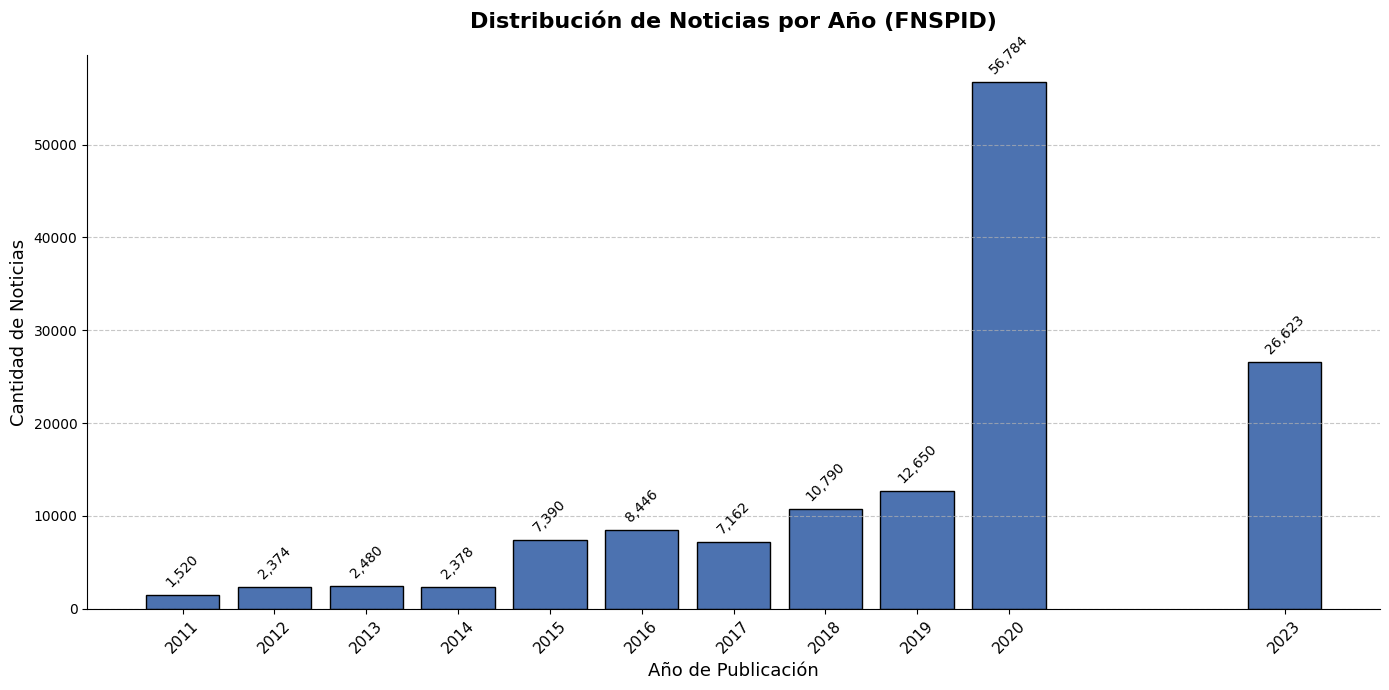

¡Gráfico guardado como:
'/content/drive/MyDrive/GIA/TFG/distribucion_golden_dataset.png'!


In [ ]:
exportar_y_graficar_dataset()

## Inferencia de FinBERT con el dataset extraído.

Se prueba a hacer una inferencia con FinBERT sobre el dataset extraído en el que se ha filtrado por hora, ticker y titular.

In [ ]:
def aplicar_finbert_a_dataset():
    print("="*60)
    print("APLICACIÓN DE FINBERT")
    print("="*60)

    device = 0 if torch.cuda.is_available() else -1

    # Cargar Dataset filtrado desde Drive
    ruta_entrada = '/content/drive/MyDrive/GIA/TFG/fnspid_dataset.parquet'
    ruta_salida = '/content/drive/MyDrive/GIA/TFG/fnspid_con_sentimiento.parquet'

    print(f"\nCargando dataset desde: {ruta_entrada}")
    df = pd.read_parquet(ruta_entrada)
    print(f"Total de noticias a analizar: {len(df):,}")

    # Descargar/Cargar el modelo FinBERT (ProsusAI)
    print("\nCargando el modelo ProsusAI/finbert...")
    analizador = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device)

    # Procesar los titulares
    titulares = df['Article_title'].tolist()
    print("\nAnalizando sentimiento")
    resultados = []

    batch_size = 128
    for i in tqdm(range(0, len(titulares), batch_size), desc="Procesando lotes"):
        batch = titulares[i:i + batch_size]
        res_batch = analizador(batch)
        resultados.extend(res_batch)

    # Extraer etiquetas y probabilidades
    df['Sentiment_Label'] = [res['label'] for res in resultados] # positive, negative, neutral
    df['Sentiment_Prob'] = [res['score'] for res in resultados]  # Nivel de confianza

    # Convertir las etiquetas de texto a números (Score)
    # Positivo = 1, Neutral = 0, Negativo = -1
    mapeo_sentimiento = {'positive': 1, 'neutral': 0, 'negative': -1}
    df['Sentiment_Score'] = df['Sentiment_Label'].map(mapeo_sentimiento)

    print(f"\nGuardando el nuevo dataset con sentimientos en: {ruta_salida}")
    df.to_parquet(ruta_salida)

    print("="*60)
    print("¡PROCESO COMPLETADO CON ÉXITO!")
    print("="*60)
    print(df[['Date', 'Stock_symbol', 'Sentiment_Label', 'Sentiment_Score']].head(5))

In [ ]:
aplicar_finbert_a_dataset()

APLICACIÓN DE FINBERT

Cargando dataset desde: /content/drive/MyDrive/GIA/TFG/fnspid_dataset.parquet
Total de noticias a analizar: 138,597

Cargando el modelo ProsusAI/finbert...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Analizando sentimientos (esto puede tardar unos minutos)...


Procesando lotes:   0%|          | 0/1083 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Guardando el nuevo dataset con sentimientos en: /content/drive/MyDrive/GIA/TFG/fnspid_con_sentimiento.parquet
¡PROCESO COMPLETADO CON ÉXITO!
                      Date Stock_symbol Sentiment_Label  Sentiment_Score
0  2020-06-05 06:30:54 UTC            A         neutral                0
1  2020-06-03 06:45:20 UTC            A         neutral                0
2  2020-05-26 00:30:07 UTC            A         neutral                0
3  2020-05-22 08:45:06 UTC            A         neutral                0
4  2020-05-22 07:38:59 UTC            A        positive                1


#### Examinación rápida de todos los ticker del dataset extraído.

In [ ]:
def extraer_todos_los_tickers():
    ruta_dataset = '/content/drive/MyDrive/GIA/TFG/fnspid_con_sentimiento.parquet'
    ruta_salida_txt = '/content/drive/MyDrive/GIA/TFG/lista_tickers_completos.txt'

    print("="*60)
    print("EXTRAYENDO LA LISTA COMPLETA DE TICKERS")
    print("="*60)

    try:
        # Cargamos el dataset
        df = pd.read_parquet(ruta_dataset)

        # Extraemos tickers únicos, quitamos espacios en blanco por si acaso y ordenamos alfabéticamente
        tickers_unicos = df['Stock_symbol'].str.strip().unique()
        tickers_unicos = sorted([str(t) for t in tickers_unicos if pd.notna(t)])

        total_tickers = len(tickers_unicos)
        print(f"Total de empresas (Tickers) únicas encontradas: {total_tickers}\n")

        with open(ruta_salida_txt, 'w') as f:
            for ticker in tickers_unicos:
                f.write(f"{ticker}\n")

        print("LISTA COMPLETA DE TICKERS:")
        print("-" * 60)

        for i in range(0, total_tickers, 15):
            lote = tickers_unicos[i:i+15]
            print(", ".join(lote))

        print("-" * 60)
        print(f"\nLa lista completa se ha guardado en: '{ruta_salida_txt}'")

        return tickers_unicos

    except FileNotFoundError:
        print(f"[!] Error: No encuentro el archivo en {ruta_dataset}")
        print("Asegúrate de que el nombre es correcto y Google Drive está montado.")
    except Exception as e:
        print(f"[!] Ocurrió un error inesperado: {e}")

In [ ]:
mis_tickers = extraer_todos_los_tickers()

EXTRAYENDO LA LISTA COMPLETA DE TICKERS
Total de empresas (Tickers) únicas encontradas: 6463

LISTA COMPLETA DE TICKERS:
------------------------------------------------------------
A, AA, AAC, AADR, AAL, AAMC, AAME, AAN, AAOI, AAON, AAP, AAPL, AAU, AAV, AAVL
AAWW, AAXJ, AB, ABAC, ABAX, ABB, ABBV, ABC, ABCB, ABCD, ABCO, ABCW, ABDC, ABEV, ABG
ABGB, ABIO, ABM, ABMD, ABR, ABT, ABTL, ABX, ABY, ACAD, ACAS, ACAT, ACC, ACCO, ACCU
ACE, ACES, ACET, ACFC, ACFN, ACG, ACGL, ACGLO, ACH, ACHC, ACHN, ACIW, ACLS, ACM, ACMP
ACN, ACNB, ACOR, ACP, ACPW, ACRE, ACRX, ACSF, ACST, ACT, ACTA, ACTG, ACTS, ACU, ACUR
ACWI, ACWV, ACWX, ACXM, ACY, ADAT, ADBE, ADC, ADEP, ADES, ADGE, ADHD, ADI, ADK, ADM
ADMA, ADMP, ADMS, ADNC, ADP, ADPT, ADRA, ADRD, ADRE, ADRU, ADS, ADSK, ADT, ADTN, ADVS
ADX, ADXS, ADZ, AE, AEB, AEC, AEE, AEG, AEGN, AEGR, AEHR, AEIS, AEL, AEM, AEO
AEP, AEPI, AER, AERI, AES, AET, AETI, AEY, AEZS, AF, AFA, AFAM, AFB, AFC, AFCB
AFFX, AFG, AFGD, AFH, AFK, AFL, AFMD, AFOP, AFSI, AFT, AG, AGA, AGC, AGCO, 

#### De todos esos tickers que tenemos en el dataset de sentimiento, filtramos para quedarnos solos con las que pertenecen actualmente al S&P500

In [ ]:
def filtrar_por_sp500():
    print("="*60)
    print("CRUZANDO EL DATASET CON EL ÍNDICE S&P 500")
    print("="*60)

    ruta_dataset = '/content/drive/MyDrive/GIA/TFG/fnspid_con_sentimiento.parquet'

    try:
        # Descargar la lista oficial del S&P 500
        print("1. Descargando componentes actuales del S&P 500 desde Wikipedia...")
        url_sp500 = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        cabeceras = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
        respuesta = requests.get(url_sp500, headers=cabeceras)
        tabla_sp500 = pd.read_html(respuesta.text)[0]


        tickers_sp500 = tabla_sp500['Symbol'].str.replace('.', '-').tolist()
        print(f"   -> ¡Obtenidos {len(tickers_sp500)} tickers del S&P 500!\n")

        # Cargamos dataset
        print("2. Cargando tu Golden Dataset con Sentimientos...")
        df = pd.read_parquet(ruta_dataset)
        total_original = len(df)

        # Filtrado
        print("3. Limpiando y filtrando...")
        df['Stock_symbol'] = df['Stock_symbol'].str.replace('.', '-')
        df_sp500 = df[df['Stock_symbol'].isin(tickers_sp500)]

        total_sp500 = len(df_sp500)
        empresas_sobrevivientes = df_sp500['Stock_symbol'].nunique()

        # Resultados
        print("\n" + "="*60)
        print("RESULTADOS DEL FILTRO S&P 500")
        print("="*60)
        print(f"Noticias totales originales: {total_original:,}")
        print(f"Noticias dentro del S&P 500: {total_sp500:,} ({(total_sp500/total_original)*100:.2f}%)")
        print(f"Empresas únicas resultantes:  {empresas_sobrevivientes} de los {len(tickers_sp500)} del índice")

        print("\nTOP 10 EMPRESAS S&P 500 CON MÁS NOTICIAS EN TU DATASET:")
        print("-" * 55)
        top10 = df_sp500['Stock_symbol'].value_counts().head(10)
        for ticker, conteo in top10.items():
            nombre_empresa = tabla_sp500[tabla_sp500['Symbol'].str.replace('.', '-') == ticker]['Security'].values[0]
            print(f"{ticker:<6} | {nombre_empresa:<25} | {conteo:>5,} noticias")

        return df_sp500

    except Exception as e:
        print(f"[!] Error inesperado: {e}")

In [ ]:
df_sp500_final = filtrar_por_sp500()

CRUZANDO EL DATASET CON EL ÍNDICE S&P 500
1. Descargando componentes actuales del S&P 500 desde Wikipedia...


/tmp/ipykernel_10595/1120311926.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tabla_sp500 = pd.read_html(respuesta.text)[0]


   -> ¡Obtenidos 503 tickers del S&P 500!

2. Cargando tu Golden Dataset con Sentimientos...
3. Limpiando y filtrando...

RESULTADOS DEL FILTRO S&P 500
Noticias totales originales: 138,597
Noticias dentro del S&P 500: 8,361 (6.03%)
Empresas únicas resultantes:  425 de los 503 del índice

TOP 10 EMPRESAS S&P 500 CON MÁS NOTICIAS EN TU DATASET:
-------------------------------------------------------
AMD    | Advanced Micro Devices    |    48 noticias
AAPL   | Apple Inc.                |    41 noticias
AMZN   | Amazon                    |    40 noticias
NVDA   | Nvidia                    |    36 noticias
TSLA   | Tesla, Inc.               |    35 noticias
GIS    | General Mills             |    34 noticias
PODD   | Insulet Corporation       |    32 noticias
XOM    | ExxonMobil                |    31 noticias
BA     | Boeing                    |    31 noticias
AON    | Aon plc                   |    31 noticias


#### Al ver que la gran mayoría de las noticias que hay en el dataset están fuera del S&P500, decidí ver cuales eran las empresas y de que tipo abarcaban la mayoría de los datos.

In [ ]:
def top_dataset():
    print("="*60)
    print("TOP 20 DATASET")
    print("="*60)

    ruta = '/content/drive/MyDrive/GIA/TFG/fnspid_con_sentimiento.parquet'

    try:
        df = pd.read_parquet(ruta)
        top20 = df['Stock_symbol'].value_counts().head(20)

        print("LOS 20 TICKERS CON MÁS NOTICIAS EN TOTAL:")
        print("-" * 40)
        for ticker, conteo in top20.items():
            porcentaje = (conteo / len(df)) * 100
            print(f"{ticker:<8} | {conteo:>6,} noticias ({porcentaje:>5.2f}%)")

    except Exception as e:
        print(f"Error: {e}")

In [ ]:
top_dataset()

TOP 20 DATASET
LOS 20 TICKERS CON MÁS NOTICIAS EN TOTAL:
----------------------------------------
PPHI     |    931 noticias ( 0.67%)
BROGW    |    872 noticias ( 0.63%)
ACGLO    |    869 noticias ( 0.63%)
BRLIU    |    833 noticias ( 0.60%)
ESGRO    |    824 noticias ( 0.59%)
BPYPO    |    590 noticias ( 0.43%)
BHFAL    |    564 noticias ( 0.41%)
OCFCP    |    550 noticias ( 0.40%)
YGYIP    |    541 noticias ( 0.39%)
FITBO    |    519 noticias ( 0.37%)
EBR-B    |    516 noticias ( 0.37%)
DHCNL    |    515 noticias ( 0.37%)
MOG-B    |    510 noticias ( 0.37%)
SOHOO    |    508 noticias ( 0.37%)
VERBW    |    477 noticias ( 0.34%)
BCDAW    |    476 noticias ( 0.34%)
NYMTN    |    450 noticias ( 0.32%)
AKO-A    |    445 noticias ( 0.32%)
AKO-B    |    445 noticias ( 0.32%)
GECCM    |    445 noticias ( 0.32%)


En el mercado financiero estadounidense, cuando un ticker tiene 5 letras y acaba en W, U, O o P, suele significar que son instrumentos financieros complejos:

- W (Warrants): Derechos de compra de acciones (ej. BROGW, VERBW).

- U (Units): Paquetes que mezclan acciones y warrants.

- O / P (Preferred): Acciones preferentes que pagan dividendos fijos.

- Los que tienen guiones (MOG-B, EBR-B) son distintas clases de acciones (Clase B).

## Tras observar que no se disponen de suficientes datos para la realización de predicción intradía, se decide trabajar con las horas por defecto.

- Se sigue empleando el dataset FNSPID.

In [ ]:
def analisis_resumenes_fnspid():
    print("="*60)
    print("EXTRACCIÓN Y GRÁFICO DE RESÚMENES FNSPID (S&P 500)")
    print("="*60)

    try:
        # Se obtiene la lista de S&P 500 de Wikipedia.
        print("1. Descargando lista actualizada del S&P 500...")
        url_sp500 = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        cabeceras = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        respuesta = requests.get(url_sp500, headers=cabeceras)
        tabla_sp500 = pd.read_html(respuesta.text)[0]
        tickers_sp500 = set(tabla_sp500['Symbol'].str.replace('.', '-'))
        print(f" -> {len(tickers_sp500)} tickers del S&P 500 cargados.\n")

        # Conectamos al dataset FNSPID en streaming
        print("2. Conectando a FNSPID en Hugging Face (Streaming)...")
        dataset = load_dataset("Zihan1004/FNSPID", data_files={"train": "Stock_news/**"}, split="train", streaming=True)
        iterator = iter(dataset.iter(batch_size=50000))

        datos_filtrados = []
        filas_procesadas = 0
        valores_nulos_falsos = ["None", "none", "NaN", "nan", "", "null", "Null"]

        print("\n3. Iniciando filtrado masivo (S&P 500 + Resumen Válido)...")
        while True:
            try:
                batch = next(iterator)
                df_batch = pd.DataFrame(batch)
                filas_procesadas += len(df_batch)

                df_batch.replace(valores_nulos_falsos, pd.NA, inplace=True)

                if all(col in df_batch.columns for col in ['Stock_symbol', 'Article_title', 'Lexrank_summary', 'Date']):

                    df_batch['Stock_symbol'] = df_batch['Stock_symbol'].astype(str).str.strip().str.upper()
                    mascara_sp500 = df_batch['Stock_symbol'].isin(tickers_sp500)
                    mascara_textos = df_batch['Lexrank_summary'].notna() & df_batch['Article_title'].notna()

                    df_valido = df_batch[mascara_sp500 & mascara_textos].copy()

                    if not df_valido.empty:
                        columnas_esenciales = ['Date', 'Stock_symbol', 'Article_title', 'Lexrank_summary']
                        datos_filtrados.append(df_valido[columnas_esenciales])

                if filas_procesadas % 2000000 == 0:
                     print(f" -> Procesadas {filas_procesadas:,} filas. Guardadas útiles: {sum(len(d) for d in datos_filtrados):,}")

            except StopIteration:
                print(f" -> Lectura finalizada. Total procesado: {filas_procesadas:,} filas.")
                break
            except Exception as e:
                print(f"\n[!] Error procesando el lote en la fila {filas_procesadas:,}: {e}")
                break

        if datos_filtrados:
            df_final = pd.concat(datos_filtrados, ignore_index=True)

            print("\n4. Procesando fechas y calculando distribución...")
            df_final['Date'] = pd.to_datetime(df_final['Date'], errors='coerce', utc=True)
            df_final = df_final.dropna(subset=['Date'])
            df_final['Year'] = df_final['Date'].dt.year.astype(int)

            fecha_min = df_final['Date'].min()
            fecha_max = df_final['Date'].max()

            print("\n" + "="*60)
            print("RESULTADOS DE LA EXTRACCIÓN (FNSPID S&P 500 + RESÚMENES)")
            print("="*60)
            print(f"Total de noticias útiles: {len(df_final):,}")
            print(f"Ventana Temporal: Desde {fecha_min.strftime('%Y-%m-%d')} hasta {fecha_max.strftime('%Y-%m-%d')}")
            print("="*60)

            print("\n5. Generando gráfico de distribución anual...")
            conteo_por_ano = df_final['Year'].value_counts().sort_index()

            plt.figure(figsize=(12, 6))
            barras = plt.bar(conteo_por_ano.index.astype(str), conteo_por_ano.values, color='#4CAF50', edgecolor='black')


            for barra in barras:
                altura = barra.get_height()
                if altura > 0:
                    plt.text(barra.get_x() + barra.get_width()/2., altura + (max(conteo_por_ano.values)*0.01),
                             f'{int(altura):,}', ha='center', va='bottom', fontsize=9, rotation=45)

            plt.title('Distribución Anual de Noticias con Resumen (S&P 500)', fontsize=15, fontweight='bold', pad=20)
            plt.xlabel('Año', fontsize=12)
            plt.ylabel('Cantidad de Noticias', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)
            plt.tight_layout()
            plt.show()

            print("\n6. MUESTRA ALEATORIA (TITULAR VS RESUMEN):")
            print("-" * 60)
            pd.set_option('display.max_colwidth', None)
            print(df_final.sample(min(3, len(df_final)))[['Stock_symbol', 'Year', 'Article_title', 'Lexrank_summary']])
            print("-" * 60)

            df_final = df_final.drop(columns=['Year'])

            print("\n7. Guardando dataset en Google Drive...")
            ruta_guardado = '/content/drive/MyDrive/GIA/TFG/fnspid_sp500_resumenes.parquet'
            df_final.to_parquet(ruta_guardado, index=False)
            print(f"Dataset guardado en: {ruta_guardado}")

            return df_final
        else:
            print("\n[!] No se encontró ninguna fila válida.")
            return None

    except Exception as e:
        print(f"\n[!] Error crítico: {e}")
        return None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


EXTRACCIÓN Y GRÁFICO DE RESÚMENES FNSPID (S&P 500)
1. Descargando lista actualizada del S&P 500...
 -> 503 tickers del S&P 500 cargados.

2. Conectando a FNSPID en Hugging Face (Streaming)...


Repo card metadata block was not found. Setting CardData to empty.



3. Iniciando filtrado masivo (S&P 500 + Resumen Válido)...
 -> Procesadas 2,000,000 filas. Guardadas útiles: 0
 -> Procesadas 4,000,000 filas. Guardadas útiles: 0
 -> Procesadas 6,000,000 filas. Guardadas útiles: 0
 -> Procesadas 8,000,000 filas. Guardadas útiles: 0
 -> Procesadas 10,000,000 filas. Guardadas útiles: 0
 -> Procesadas 12,000,000 filas. Guardadas útiles: 0
 -> Procesadas 14,000,000 filas. Guardadas útiles: 298,398
 -> Procesadas 16,000,000 filas. Guardadas útiles: 729,565
 -> Procesadas 18,000,000 filas. Guardadas útiles: 729,565
 -> Procesadas 20,000,000 filas. Guardadas útiles: 729,565
 -> Procesadas 22,000,000 filas. Guardadas útiles: 729,565
 -> Procesadas 24,000,000 filas. Guardadas útiles: 729,565
 -> Procesadas 26,000,000 filas. Guardadas útiles: 729,565
 -> Procesadas 28,000,000 filas. Guardadas útiles: 729,565
 -> Lectura finalizada. Total procesado: 28,606,813 filas.

4. Procesando fechas y calculando distribución...

RESULTADOS DE LA EXTRACCIÓN (FNSPID S&P 500

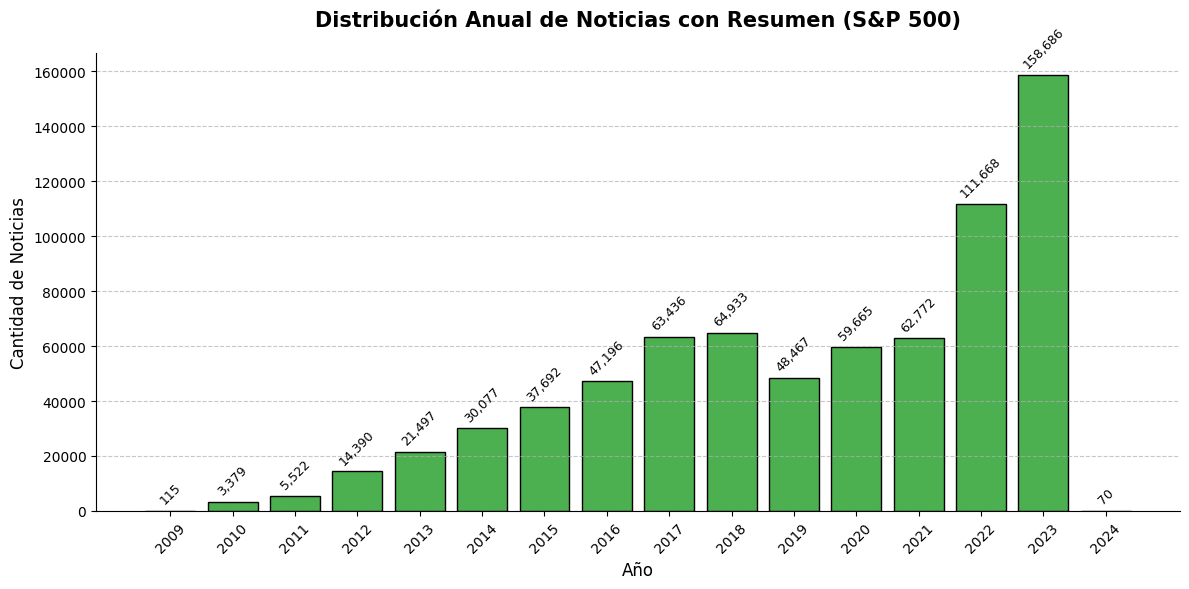


6. MUESTRA ALEATORIA (TITULAR VS RESUMEN):
------------------------------------------------------------
       Stock_symbol  Year  \
500374          NUE  2020   
430600          MLM  2015   
446608           MS  2023   

                                                                                 Article_title  \
500374                                           Notable Tuesday Option Activity: NUE, DHI, FE   
430600  United States Lime & Minerals, Inc. (USLM) Ex-Dividend Date Scheduled for May 27, 2015   
446608                                            3 Stocks Hedge Funds Are Loading Up on in Q4   

                                                                                                                                                                                                                                                                                                                                                                                                 

,Date,Stock_symbol,Article_title,Lexrank_summary
0,2023-12-16 23:00:00+00:00,A,Interesting A Put And Call Options For August 2024,"At Stock Options Channel, our YieldBoost formula has looked up and down the A options chain for the new August 2024 contracts and identified one put and one call contract of particular interest. Should the contract expire worthless, the premium would represent a 3.60% return on the cash commitment, or 5.45% annualized — at Stock Options Channel we call this the YieldBoost. Below is a chart showing A's trailing twelve month trading history, with the $150.00 strike highlighted in red: Considering the fact that the $150.00 strike represents an approximate 8% premium to the current trading price of the stock (in other words it is out-of-the-money by that percentage), there is also the possibility that the covered call contract would expire worthless, in which case the investor would keep both their shares of stock and the premium collected."
1,2023-12-12 00:00:00+00:00,A,Wolfe Research Initiates Coverage of Agilent Technologies (A) with Outperform Recommendation,"The projected annual revenue for Agilent Technologies is 7,130MM, an increase of 4.35%. At the current share price of $133.74 / share, the stock's dividend yield is 0.71%. Additionally, the company's dividend payout ratio is 0.22."
2,2023-12-12 00:00:00+00:00,A,Agilent Technologies Reaches Analyst Target Price,"When a stock reaches the target an analyst has set, the analyst logically has two ways to react: downgrade on valuation, or, re-adjust their target price to a higher level. Analyst reaction may also depend on the fundamental business developments that may be responsible for driving the stock price higher — if things are looking up for the company, perhaps it is time for that target price to be raised. There are 14 different analyst targets within the Zacks coverage universe contributing to that average for Agilent Technologies, Inc., but the average is just that — a mathematical average."
3,2023-12-07 00:00:00+00:00,A,Agilent (A) Enhances BioTek Cytation C10 With New Technology,"Notably, Agilent enhanced the BioTek Cytation C10 confocal imaging reader with the addition of water immersion and confocal spinning disk technology. Agilent Technologies, Inc. Price and Consensus Agilent Technologies, Inc. price-consensus-chart | Agilent Technologies, Inc. Quote Growth Prospects The latest move positions the company well to strengthen its footing in the global microplate reader and live cell imaging markets. All the abovementioned endeavors are likely to aid the performance of the ACG segment in the days ahead."
4,2023-12-07 00:00:00+00:00,A,"Pre-Market Most Active for Dec 7, 2023 : SQQQ, PLTR, TQQQ, ALT, UBER, PFE, GILD, MRK, AMD, NIO, JBLU, AI","The NASDAQ 100 Pre-Market Indicator is up 70.21 to 15,858.26. Over the last four weeks they have had 6 up revisions for the earnings forecast, for the fiscal quarter ending Dec 2023. C3.ai, Inc. (AI) is -2.88 at $26.28, with 641,132 shares traded."
...,...,...,...,...
729560,2013-02-04 00:00:00+00:00,ZTS,Zoetis Commences Trading - Analyst Blog,"Zoetis Inc. ( ZTS ), the former Animal Health business of Pfizer Inc. ( PFE ), started trading on the New York Stock Exchange from Feb1, 2013. KKR & CO LP (KKR): Free Stock Analysis Report PFIZER INC (PFE): Free Stock Analysis Report SANOFI-AVENTIS (SNY): Free Stock Analysis Report (ZTS): ETF Research Reports To read this article on Zacks.com click here. Zoetis had priced over 86 million shares of Class A common stock at $26 per share."
729561,2013-02-01 00:00:00+00:00,ZTS,"Weekly recap: Most January pricings since 2006, Zoetis surges in debut","Pfizer's animal health care unit, Zoetis ( ZTS ), which was the largest IPO from a US company since Facebook ( FB ) after raising $2.2 billion, priced above the range at $26 and closed the day up 19% at $31. Though pricings to start the year could signal healthy deal flow in the coming months, it is also possible that J

In [ ]:
analisis_resumenes_fnspid()

#### Visualizamos que empresas tienen un mayor número de noticias del dataset de resumen comprendido entre 2010 y 2023.


In [ ]:
def analizar_top_empresas_2010_2023():
    print("="*60)
    print("ANÁLISIS DE VOLUMEN POR EMPRESA (PERIODO 2010 - 2023)")
    print("="*60)

    # Ruta del archivo que guardamos en el paso anterior
    ruta_parquet = '/content/drive/MyDrive/GIA/TFG/fnspid_sp500_resumenes.parquet'

    try:
        # Cargarmos el dataset
        print("Cargando el dataset de resúmenes del S&P 500...")
        df = pd.read_parquet(ruta_parquet)

        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df['Year'] = df['Date'].dt.year

        # Filtramos entre 2010 y 2023
        print("Filtrando la ventana temporal: 2010 <= Año <= 2023...")
        df_filtrado = df[(df['Year'] >= 2010) & (df['Year'] <= 2023)].copy()

        total_previo = len(df)
        total_filtrado = len(df_filtrado)

        print(f"\nNoticias totales en el dataset: {total_previo:,}")
        print(f"Noticias dentro del periodo 2010-2023: {total_filtrado:,}")
        print("-" * 60)

        # Calculamos y mostramos el Top 20 de empresas con más noticias
        conteo_empresas = df_filtrado['Stock_symbol'].value_counts()
        print("\nTOP 20 EMPRESAS CON MÁS NOTICIAS (2010-2023):")
        print("-" * 40)
        for ticker, cantidad in conteo_empresas.head(20).items():
            print(f" -> {ticker:<5}: {cantidad:>7,} noticias")

        print("\nGenerando gráfico del Top 20...")
        top_20 = conteo_empresas.head(20).sort_values(ascending=True)
        plt.figure(figsize=(10, 8))
        barras = plt.barh(top_20.index, top_20.values, color='#1f77b4', edgecolor='black', alpha=0.8)

        for barra in barras:
            ancho = barra.get_width()
            plt.text(ancho + (max(top_20.values)*0.01), barra.get_y() + barra.get_height()/2,
                     f'{int(ancho):,}', va='center', ha='left', fontsize=10)

        plt.title('Top 20 S&P 500: Volumen de Noticias con Resumen (2010 - 2023)', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Cantidad de Noticias', fontsize=12)
        plt.ylabel('Ticker (S&P 500)', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

        return conteo_empresas

    except FileNotFoundError:
        print(f"[!] No se ha encontrado el archivo en {ruta_parquet}.")
        print("¿Seguro que lo guardaste correctamente en el paso anterior?")
    except Exception as e:
        print(f"[!] Error inesperado: {e}")

ANÁLISIS DE VOLUMEN POR EMPRESA (PERIODO 2010 - 2023)
Cargando el dataset de resúmenes del S&P 500...
Filtrando la ventana temporal: 2010 <= Año <= 2023...

Noticias totales en el dataset: 729,565
Noticias dentro del periodo 2010-2023: 729,380
------------------------------------------------------------

TOP 20 EMPRESAS CON MÁS NOTICIAS (2010-2023):
----------------------------------------
 -> T    :   9,449 noticias
 -> AMD  :   8,889 noticias
 -> AAPL :   8,865 noticias
 -> MSFT :   8,737 noticias
 -> GS   :   8,730 noticias
 -> GOOG :   8,726 noticias
 -> NVDA :   8,716 noticias
 -> TSLA :   8,712 noticias
 -> DIS  :   8,711 noticias
 -> WFC  :   8,689 noticias
 -> CVX  :   8,688 noticias
 -> INTC :   8,682 noticias
 -> GE   :   8,680 noticias
 -> WMT  :   8,675 noticias
 -> KO   :   7,640 noticias
 -> MRK  :   7,434 noticias
 -> GILD :   7,401 noticias
 -> NKE  :   7,126 noticias
 -> CMCSA:   6,953 noticias
 -> V    :   6,945 noticias

Generando gráfico del Top 20...


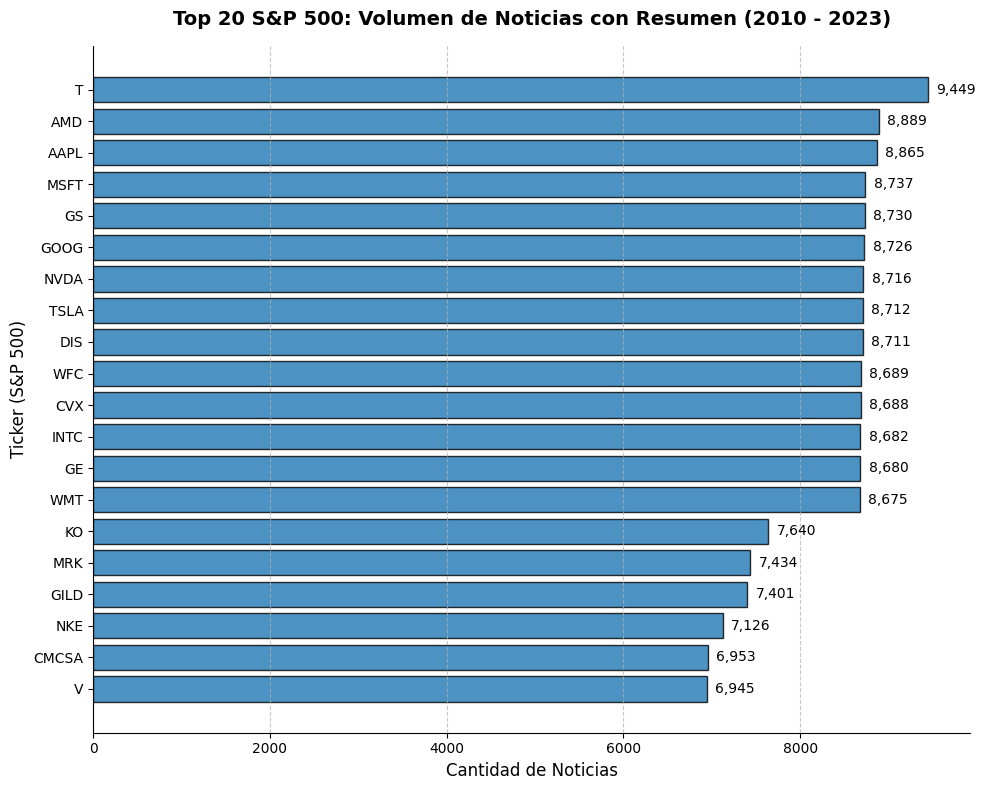

,count
Stock_symbol,
T,9449
AMD,8889
AAPL,8865
MSFT,8737
GS,8730
...,...
AVGO,7
AOS,7
AXP,7


In [ ]:
analizar_top_empresas_2010_2023()

## Inferencia con FinBERT

- Esos datos nos indican que ahora si se cuentan con un mayor número de noticias en global como en gigantes tecnológicos del S&P 500.

- Primero vamos a realizar una pequeña prueba en la que se procesan 1000 entradas para estimar el tiempo que puede llevar realizar la inferencia usando solo los resúmenes o sólo los titulares, debido que ahora contamos con muchos más datos. Con esto podemos determinar como económizar el tiempo para el uso del equipo.

In [ ]:
def estimar_tiempos_finbert():
    print("="*60)
    print("PRUEBA DE RENDIMIENTO: TITULARES VS RESÚMENES (1,000 FILAS)")
    print("="*60)

    ruta_entrada = '/content/drive/MyDrive/GIA/TFG/fnspid_sp500_resumenes.parquet'

    try:
        # Cargamos y preparamos datos
        print("1. Cargando datos y seleccionando muestra de 1,000 filas...")
        df = pd.read_parquet(ruta_entrada)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df['Year'] = df['Date'].dt.year
        df = df[(df['Year'] >= 2010) & (df['Year'] <= 2023)]

        total_real = len(df)

        df_prueba = df.head(1000).copy()

        # Configuración del hardware y modelo
        device = 0 if torch.cuda.is_available() else -1
        if device == 0:
            print("\nGPU detectada. Iniciando prueba")
        else:
            print("\nADVERTENCIA: Usando CPU. Esto será muy lento.")

        print("Cargando modelo ProsusAI/finbert...")
        analizador = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device, batch_size=64)

        titulares = df_prueba['Article_title'].astype(str).tolist()
        resumenes = df_prueba['Lexrank_summary'].astype(str).tolist()

        # Tiempo en procesar Titulares
        print("\n2. Procesando 1,000 Titulares (Cronómetro en marcha)...")
        inicio_titulares = time.time()
        _ = analizador(titulares, truncation=True, max_length=512)
        fin_titulares = time.time()
        tiempo_titulares = fin_titulares - inicio_titulares

        # Tiempo en procesarResúmenes
        print("3. Procesando 1,000 Resúmenes (Cronómetro en marcha)...")
        inicio_resumenes = time.time()
        _ = analizador(resumenes, truncation=True, max_length=512)
        fin_resumenes = time.time()
        tiempo_resumenes = fin_resumenes - inicio_resumenes

        print("\n" + "="*60)
        print("RESULTADOS DE LA PRUEBA Y ESTIMACIONES")
        print("="*60)

        print(f"Tiempo real en procesar 1,000 Titulares: {tiempo_titulares:.2f} segundos")
        print(f"Tiempo real en procesar 1,000 Resúmenes: {tiempo_resumenes:.2f} segundos")

        factor_multiplicador = total_real / 1000
        est_titulares_min = (tiempo_titulares * factor_multiplicador) / 60
        est_resumenes_min = (tiempo_resumenes * factor_multiplicador) / 60

        print("\nPROYECCIÓN PARA EL DATASET COMPLETO (2010-2023):")
        print(f" -> Total de noticias a procesar: {total_real:,}")
        print("-" * 40)
        print(f" -> Tiempo estimado para TODOS los Titulares: {est_titulares_min:.2f} minutos ({est_titulares_min/60:.2f} horas)")
        print(f" -> Tiempo estimado para TODOS los Resúmenes: {est_resumenes_min:.2f} minutos ({est_resumenes_min/60:.2f} horas)")
        print("="*60)

    except FileNotFoundError:
        print(f"[!] Error: No se encuentra el archivo en {ruta_entrada}")
    except Exception as e:
        print(f"[!] Error inesperado: {e}")

In [ ]:
estimar_tiempos_finbert()

PRUEBA DE RENDIMIENTO: TITULARES VS RESÚMENES (1,000 FILAS)
1. Cargando datos y seleccionando muestra de 1,000 filas...

[OK] GPU detectada. Iniciando prueba de velocidad...
Cargando modelo ProsusAI/finbert...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


2. Procesando 1,000 Titulares (Cronómetro en marcha)...
3. Procesando 1,000 Resúmenes (Cronómetro en marcha)...

RESULTADOS DE LA PRUEBA Y ESTIMACIONES
Tiempo real en procesar 1,000 Titulares: 3.09 segundos
Tiempo real en procesar 1,000 Resúmenes: 12.37 segundos

PROYECCIÓN PARA EL DATASET COMPLETO (2010-2023):
 -> Total de noticias a procesar: 729,380
----------------------------------------
 -> Tiempo estimado para TODOS los Titulares: 37.62 minutos (0.63 horas)
 -> Tiempo estimado para TODOS los Resúmenes: 150.38 minutos (2.51 horas)


- Se comienza realizando la inferencia del FinBERT con los titulares de las noticias sacando su score y etiqueta de sentimiento.

In [ ]:
def finbert_titulares():
    print("="*60)
    print("FASE 1: INFERENCIA DE TITULARES FINBERT")
    print("="*60)

    ruta_entrada = '/content/drive/MyDrive/GIA/TFG/fnspid_sp500_resumenes.parquet'
    ruta_salida = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares.parquet'

    try:
        print("Cargando dataset y filtrando años (2010-2023)...")
        df = pd.read_parquet(ruta_entrada)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df['Year'] = df['Date'].dt.year
        df = df[(df['Year'] >= 2010) & (df['Year'] <= 2023)].copy()

        device = 0 if torch.cuda.is_available() else -1
        print("Cargando modelo ProsusAI/finbert en GPU...")
        analizador = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device, batch_size=64)

        titulares = df['Article_title'].astype(str).tolist()

        print(f"\nProcesando {len(titulares):,} Titulares")
        resultados = []
        for salida in tqdm(analizador(titulares, truncation=True, max_length=512), total=len(titulares), desc="Titulares"):
            resultados.append((salida['label'], salida['score']))

        # Guardar en DataFrame
        df['Title_Sentiment'] = [res[0] for res in resultados]
        df['Title_Score'] = [res[1] for res in resultados]

        # Limpieza y guardado
        df = df.drop(columns=['Year'])
        df.to_parquet(ruta_salida, index=False)

        print("\n" + "="*60)
        print(f"Inferencia con titulares completado. Guardado a salvo en:\n{ruta_salida}")
        print("="*60)

    except Exception as e:
        print(f"[!] Error crítico: {e}")

In [ ]:
finbert_titulares()

FASE 1: INFERENCIA DE TITULARES FINBERT
Cargando dataset y filtrando años (2010-2023)...
Cargando modelo ProsusAI/finbert en GPU...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Procesando 729,380 Titulares


Titulares:   0%|          | 0/729380 [00:00<?, ?it/s]


Inferencia con titulares completado. Guardado a salvo en:
/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares.parquet


Tardó en ejecutarse 33 min con GPU.

#### Ahora vamos a realizar la inferencia usando los resumenes.

In [ ]:
def fnspid_finbert_titulares_resumenes():
    print("="*60)
    print("FASE 2: INFERENCIA DE RESÚMENES FINBERT")
    print("="*60)

    tiempo_inicio = time.time()

    # IMPORTANTE: La entrada es el archivo que generó la Fase 1
    ruta_entrada = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares.parquet'
    ruta_salida_final = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet'

    try:
        # Cargamos datos con los titulares ya procesados
        print("1. Cargando dataset ...")
        df = pd.read_parquet(ruta_entrada)

        # Configuración Modelo
        device = 0 if torch.cuda.is_available() else -1
        print("2. Cargando modelo ProsusAI/finbert en GPU...")
        analizador = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device, batch_size=64)

        resumenes = df['Lexrank_summary'].astype(str).tolist()

        # Inferencia
        print(f"\n3. Procesando {len(resumenes):,} Resúmenes.")
        resultados = []
        for salida in tqdm(analizador(resumenes, truncation=True, max_length=512), total=len(resumenes), desc="Resúmenes"):
            resultados.append((salida['label'], salida['score']))

        print("\n4. Uniendo datos y guardando archivo definitivo...")
        df['Summary_Sentiment'] = [res[0] for res in resultados]
        df['Summary_Score'] = [res[1] for res in resultados]

        df.to_parquet(ruta_salida_final, index=False)

        tiempo_fin = time.time()
        segundos_totales = tiempo_fin - tiempo_inicio

        horas = int(segundos_totales // 3600)
        minutos = int((segundos_totales % 3600) // 60)
        segundos = int(segundos_totales % 60)

        print("\n" + "="*60)
        print(f"INFERENCIA COMPLETADA CON ÉXITO.")
        print(f" -> Dataset maestro guardado en:\n{ruta_salida_final}")
        print("-" * 60)
        print(f"TIEMPO TOTAL DE EJECUCIÓN: {horas}h {minutos}m {segundos}s")
        print("="*60)

    except FileNotFoundError:
        print("Error: No encuentro el archivo.")
    except Exception as e:
        print(f"Error crítico: {e}")

In [ ]:
fnspid_finbert_titulares_resumenes()

FASE 2: INFERENCIA DE RESÚMENES FINBERT (CON CRONÓMETRO)
1. Cargando dataset ...
2. Cargando modelo ProsusAI/finbert en GPU...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



3. Procesando 729,380 Resúmenes.


Resúmenes:   0%|          | 0/729380 [00:00<?, ?it/s]


4. Uniendo datos y guardando archivo definitivo...

INFERENCIA COMPLETADA CON ÉXITO.
 -> Dataset maestro guardado en:
/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet
------------------------------------------------------------
TIEMPO TOTAL DE EJECUCIÓN: 4h 5m 18s


#### Visualizamos las 5 primeras entradas de este nuevo dataset para ver comprobar el resultado obtenido.

In [ ]:
def visualizar_dataset_final():
    ruta_final = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet'

    try:
        # Cargamos el dataset definitivo
        df = pd.read_parquet(ruta_final)

        print("="*80)
        print("MUESTRA DEL DATASET MAESTRO (FINBERT DUAL)")
        print(f"Total de registros: {len(df):,}")
        print("="*80)

        # Configurar visualización para que no se corte el texto
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        pd.set_option('display.max_colwidth', 100) # Ajustado para leer bien el resumen

        # Seleccionamos las columnas clave para la comparativa
        columnas_ordenadas = [
            'Stock_symbol', 'Date',
            'Title_Sentiment', 'Title_Score',
            'Summary_Sentiment', 'Summary_Score',
            'Article_title', 'Lexrank_summary'
        ]

        # Mostramos las 5 primeras entradas
        display(df[columnas_ordenadas].head(5))

    except FileNotFoundError:
        print(f"[!] No se encuentra el archivo en: {ruta_final}")
    except Exception as e:
        print(f"[!] Error al visualizar: {e}")

In [ ]:
visualizar_dataset_final()

MUESTRA DEL DATASET MAESTRO (FINBERT DUAL)
Total de registros: 729,380


,Stock_symbol,Date,Title_Sentiment,Title_Score,Summary_Sentiment,Summary_Score,Article_title,Lexrank_summary
0,A,2023-12-16 23:00:00+00:00,neutral,0.948595,neutral,0.924886,Interesting A Put And Call Options For August 2024,"At Stock Options Channel, our YieldBoost formula has looked up and down the A options chain for ..."
1,A,2023-12-12 00:00:00+00:00,positive,0.902089,positive,0.552936,Wolfe Research Initiates Coverage of Agilent Technologies (A) with Outperform Recommendation,"The projected annual revenue for Agilent Technologies is 7,130MM, an increase of 4.35%. At the c..."
2,A,2023-12-12 00:00:00+00:00,positive,0.879278,neutral,0.916606,Agilent Technologies Reaches Analyst Target Price,"When a stock reaches the target an analyst has set, the analyst logically has two ways to react:..."
3,A,2023-12-07 00:00:00+00:00,positive,0.748675,positive,0.942462,Agilent (A) Enhances BioTek Cytation C10 With New Technology,"Notably, Agilent enhanced the BioTek Cytation C10 confocal imaging reader with the addition of w..."
4,A,2023-12-07 00:00:00+00:00,neutral,0.948648,positive,0.864840,"Pre-Market Most Active for Dec 7, 2023 : SQQQ, PLTR, TQQQ, ALT, UBER, PFE, GILD, MRK, AMD, NIO, ...","The NASDAQ 100 Pre-Market Indicator is up 70.21 to 15,858.26. Over the last four weeks they have..."


## Comparativa discretizada entre Titulares y resumenes

- Convertir las etiquetas de texto (positive, neutral, negative) en 1, 0, -1 para los titulares y para los resúmenes.

- Calcular la Matriz de Confusión para ver visualmente dónde coinciden y dónde discrepan.

- Calcular la Distancia Discreta Media (el error absoluto entre ambas decisiones).

Tambien hacemos un análisis de como queda el data en cuanto a confianza media por estrategia así como número de etiquetas en cada una y sus respectivos porcentajes tanto por estrategia como globales.

In [ ]:
def analizar_distribucion_y_confianza():
    print("="*65)
    print("ANÁLISIS DE DISTRIBUCIÓN Y CONFIANZA: TITULARES VS RESÚMENES")
    print("="*65)

    ruta_archivo = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet'

    try:
        # 1. Carga de datos
        df = pd.read_parquet(ruta_archivo)
        total_filas = len(df)

        col_tit_sent = 'Title_Sentiment'
        col_tit_score = 'Title_Score'
        col_res_sent = 'Summary_Sentiment'
        col_res_score = 'Summary_Score'

        # Función auxiliar para generar las estadísticas por estrategia
        def generar_estadisticas(col_sentimiento, col_confianza, nombre_estrategia):
            stats = df.groupby(col_sentimiento).agg(
                Cantidad=(col_sentimiento, 'count'),
                Confianza_Media=(col_confianza, 'mean')
            ).reset_index()

            stats['Porcentaje (%)'] = (stats['Cantidad'] / total_filas) * 100
            orden = {'positive': 1, 'neutral': 2, 'negative': 3}
            stats['orden'] = stats[col_sentimiento].map(orden)
            stats = stats.sort_values('orden').drop('orden', axis=1)

            print(f"\n--- ESTRATEGIA: {nombre_estrategia.upper()} ---")
            print(f"Total de textos analizados: {total_filas:,}")
            print("-" * 50)

            for index, row in stats.iterrows():
                etiqueta = row[col_sentimiento].capitalize()
                cantidad = int(row['Cantidad'])
                pct = row['Porcentaje (%)']
                confianza = row['Confianza_Media']

                print(f"{etiqueta:<10} | Cantidad: {cantidad:<7,} | Pct: {pct:>5.2f}% | Confianza Media: {confianza:.4f}")


            confianza_global = df[col_confianza].mean()
            print("-" * 50)
            print(f"TOTAL      | Cantidad: {total_filas:<7,} | Pct: 100.00% | CONFIANZA GLOBAL: {confianza_global:.4f}")

        # Ejecutamos el análisis para ambas estrategias
        generar_estadisticas(col_tit_sent, col_tit_score, "Titulares")
        generar_estadisticas(col_res_sent, col_res_score, "Resúmenes")

    except FileNotFoundError:
        print(f"[!] Error: No se encontró el archivo en {ruta_archivo}")
    except KeyError as e:
        print(f"[!] Error de columnas: No se encuentra la columna {e} en el dataset.")
        print("    Verifica cómo se llaman las columnas del score de FinBERT en tu Parquet.")
    except Exception as e:
        print(f"[!] Error crítico: {e}")

In [ ]:
analizar_distribucion_y_confianza()

ANÁLISIS DE DISTRIBUCIÓN Y CONFIANZA: TITULARES VS RESÚMENES

--- ESTRATEGIA: TITULARES ---
Total de textos analizados: 729,380
--------------------------------------------------
Positive   | Cantidad: 147,552 | Pct: 20.23% | Confianza Media: 0.8026
Neutral    | Cantidad: 479,899 | Pct: 65.80% | Confianza Media: 0.8629
Negative   | Cantidad: 101,929 | Pct: 13.97% | Confianza Media: 0.8329
--------------------------------------------------
TOTAL      | Cantidad: 729,380 | Pct: 100.00% | CONFIANZA GLOBAL: 0.8465

--- ESTRATEGIA: RESÚMENES ---
Total de textos analizados: 729,380
--------------------------------------------------
Positive   | Cantidad: 232,370 | Pct: 31.86% | Confianza Media: 0.8273
Neutral    | Cantidad: 314,759 | Pct: 43.15% | Confianza Media: 0.8346
Negative   | Cantidad: 182,251 | Pct: 24.99% | Confianza Media: 0.8706
--------------------------------------------------
TOTAL      | Cantidad: 729,380 | Pct: 100.00% | CONFIANZA GLOBAL: 0.8413


Para que una red LSTM aprenda a predecir subidas o bajadas en bolsa, necesita varianza, es decir, necesita "señales" claras.

- Titulares: Tienen un 65.80% de noticias neutras. Esto significa que dos de cada tres días le vas a pasar a la red neuronal una señal plana (0). Un modelo no puede aprender a predecir volatilidad si su variable principal casi siempre le dice "aquí no pasa nada".

- Resúmenes: Reducen la neutralidad al 43.15%. Esto significa que más de la mitad de las veces (56.85%), los resúmenes le están dando a la IA una pista direccional clara (positiva o negativa) para que cruce con el precio.

In [ ]:
def comparativa_discreta_titular_vs_resumen():
    print("="*60)
    print("FASE DE VALIDACIÓN: TITULAR VS RESUMEN (DISCRETO)")
    print("="*60)

    ruta_archivo = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet'

    try:
        print("1. Cargando dataset...")
        df = pd.read_parquet(ruta_archivo)
        total_filas = len(df)

        # Mapeo a discreto (-1, 0, 1)
        print("2. Discretizando etiquetas (-1, 0, 1)...")
        mapeo = {'positive': 1, 'neutral': 0, 'negative': -1}

        df['Title_Discrete'] = df['Title_Sentiment'].map(mapeo)
        df['Summary_Discrete'] = df['Summary_Sentiment'].map(mapeo)

        # Calculamos Distancias y Coincidencias
        df['Discrete_Distance'] = np.abs(df['Title_Discrete'] - df['Summary_Discrete'])

        distancia_media = df['Discrete_Distance'].mean()
        coincidencias = (df['Discrete_Distance'] == 0).sum()

        print("\n" + "-"*50)
        print("RESULTADOS DE LA MÉTRICA DE DISTANCIA")
        print("-"*50)
        print(f"Noticias totales analizadas: {total_filas:,}")
        print(f"Acuerdo exacto (Mismo sentimiento): {coincidencias:,} ({(coincidencias/total_filas)*100:.2f}%)")
        print(f"Distancia media global: {distancia_media:.4f}")
        print(" -> Nota: 0 significa que son idénticos, 2 significa que son opuestos.")

        # Matriz de Confusión
        print("\n3. Generando Matriz de Confusión...")
        etiquetas = [-1, 0, 1]
        cm = confusion_matrix(df['Title_Discrete'], df['Summary_Discrete'], labels=etiquetas)

        # Dibujar el Heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Negativo (-1)', 'Neutro (0)', 'Positivo (1)'],
                    yticklabels=['Negativo (-1)', 'Neutro (0)', 'Positivo (1)'])

        plt.title('Matriz de Confusión: Sentimiento Titular vs Resumen', fontsize=14, pad=15, fontweight='bold')
        plt.xlabel('Sentimiento del RESUMEN', fontsize=12, fontweight='bold')
        plt.ylabel('Sentimiento del TITULAR', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"[!] Error: No se encontró el archivo en {ruta_archivo}")
    except Exception as e:
        print(f"[!] Error crítico: {e}")

FASE DE VALIDACIÓN: TITULAR VS RESUMEN (DISCRETO)
1. Cargando dataset...
2. Discretizando etiquetas (-1, 0, 1)...

--------------------------------------------------
RESULTADOS DE LA MÉTRICA DE DISTANCIA
--------------------------------------------------
Noticias totales analizadas: 729,380
Acuerdo exacto (Mismo sentimiento): 382,442 (52.43%)
Distancia media global: 0.5464
 -> Nota: 0 significa que son idénticos, 2 significa que son opuestos.

3. Generando Matriz de Confusión...


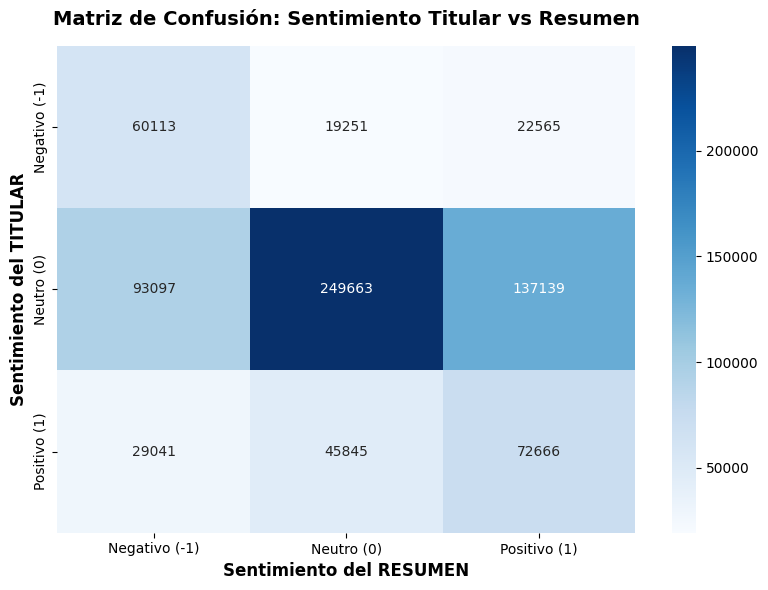

In [ ]:
comparativa_discreta_titular_vs_resumen()

## Implementar medias por día y decaimiento temporal

Para poder alimentar la red neuronal LSTM, necesitamos transformar nuestras inferencias estáticas en una **serie temporal continua e ininterrumpida**.

1. **Score Continuo Polarizado:** Convertimos la inferencia discreta en una variable numérica continua en el rango `[-1.0, 1.0]`, multiplicando la polaridad (-1, 0, 1) por la probabilidad (confianza) devuelta por FinBERT.
2. **Agregación Diaria:** Agrupamos las noticias por `Stock_symbol` y `Date` calculando la media aritmética. Esto nos da un sentimiento neto por día y evita el sesgo de sobredimensión en días con alta densidad de noticias.
3. **Manejo de Valores Nulos (Data Gaps) y Decaimiento:** El LSTM requiere un calendario sin saltos. Rellenamos los días sin noticias publicadas aplicando una función de decaimiento exponencial, que disipa la memoria de la última noticia progresivamente hacia el valor neutro (0).

La fórmula de decaimiento implementada (con $\lambda = 0.03$) es:

$$S(t) = S(0) \cdot e^{-\lambda \cdot t}$$

*Donde $S(t)$ es el sentimiento hoy, $S(0)$ es el sentimiento del último día con noticias, $t$ son los días transcurridos.*


In [ ]:
def decaimiento_temporal_paper_fnspid():
    print("="*60)
    print("APLICANDO MÉTODO DEL PAPER: MEDIAS Y DECAIMIENTO EXPONENCIAL")
    print("="*60)

    ruta_archivo = '/content/drive/MyDrive/GIA/TFG/fnspid_finbert_titulares_resumenes.parquet'
    ruta_salida_series = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    try:
        # Cargamos datos
        print("1. Cargando dataset maestro...")
        df = pd.read_parquet(ruta_archivo)

        # Polarización a escala [-1, 1] (0 es neutro)
        print("2. Calculando Score Continuo del Resumen (-1.0 a 1.0)...")
        mapeo = {'positive': 1, 'neutral': 0, 'negative': -1}
        if 'Summary_Discrete' not in df.columns:
            df['Summary_Discrete'] = df['Summary_Sentiment'].map(mapeo)

        df['Summary_Continuous'] = df['Summary_Discrete'] * df['Summary_Score']

        # Media por día
        print("3. Agrupando y calculando medias diarias por empresa...")
        df['Date_Only'] = pd.to_datetime(df['Date']).dt.date
        df_diario = df.groupby(['Stock_symbol', 'Date_Only'])['Summary_Continuous'].mean().reset_index()
        df_diario = df_diario.rename(columns={'Summary_Continuous': 'Daily_Sentiment'})
        df_diario['Date_Only'] = pd.to_datetime(df_diario['Date_Only'])

        # Rellenamos huecos y aplicamos la fórmula
        print("4. Rellenando días sin noticias y aplicando decaimiento (λ = 0.03)...")

        resultados = []
        lam = 0.03

        # Procesamos empresa por empresa para no mezclar calendarios
        for ticker, grupo in df_diario.groupby('Stock_symbol'):
            fecha_min = grupo['Date_Only'].min()
            fecha_max = grupo['Date_Only'].max()
            rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq='D')

            grupo = grupo.set_index('Date_Only').reindex(rango_fechas).rename_axis('Date_Only').reset_index()
            grupo['Stock_symbol'] = ticker

            valores_finales = []
            ultimo_valor = 0
            dias_desde_noticia = 0

            for valor_actual in grupo['Daily_Sentiment']:
                if pd.notna(valor_actual):
                    # Hay noticia este día: actualizamos el día 0 y reseteamos el tiempo
                    ultimo_valor = valor_actual
                    dias_desde_noticia = 0
                    valores_finales.append(valor_actual)
                else:
                    # No hay noticia (Data Gap): aplicamos decaimiento
                    dias_desde_noticia += 1
                    valor_decaimiento = ultimo_valor * np.exp(-lam * dias_desde_noticia)
                    valores_finales.append(valor_decaimiento)

            grupo['Sentiment_Paper_Decay'] = valores_finales
            resultados.append(grupo)

        df_final = pd.concat(resultados, ignore_index=True)

        df_final.to_parquet(ruta_salida_series, index=False)

        print("\n" + "="*60)
        print(f"[OK] Serie temporal generada y guardada con éxito en:\n{ruta_salida_series}")
        print("="*60)

        print("\nMUESTRA DEL DECAIMIENTO (Observa los días sin Daily_Sentiment):")
        print("-" * 80)
        ticker_ejemplo = df_final['Stock_symbol'].iloc[0]
        muestra = df_final[df_final['Stock_symbol'] == ticker_ejemplo].head(15)
        print(muestra)
        print("-" * 80)

        return df_final

    except Exception as e:
        print(f"[!] Error: {e}")
        return None

In [ ]:
df_paper = decaimiento_temporal_paper_fnspid()

APLICANDO MÉTODO DEL PAPER: MEDIAS Y DECAIMIENTO EXPONENCIAL
1. Cargando dataset maestro...
2. Calculando Score Continuo del Resumen (-1.0 a 1.0)...
3. Agrupando y calculando medias diarias por empresa...
4. Rellenando días sin noticias y aplicando decaimiento (λ = 0.03)...

[OK] Serie temporal generada y guardada con éxito en:
/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet

MUESTRA DEL DECAIMIENTO (Observa los días sin Daily_Sentiment):
--------------------------------------------------------------------------------
    Date_Only Stock_symbol  Daily_Sentiment  Sentiment_Paper_Decay
0  2022-09-11            A         0.000000               0.000000
1  2022-09-12            A              NaN               0.000000
2  2022-09-13            A              NaN               0.000000
3  2022-09-14            A              NaN               0.000000
4  2022-09-15            A         0.953759               0.953759
5  2022-09-16            A         0.000000               0.0

Comprobamos que el decaimiento este funcionando, buscando filas donde esté cayendo

In [ ]:
muestra_decaimiento = df_paper[(df_paper['Sentiment_Paper_Decay'] > 0.1) & (df_paper['Sentiment_Paper_Decay'] < 0.9)].head(10)
print(muestra_decaimiento[['Date_Only', 'Stock_symbol', 'Daily_Sentiment', 'Sentiment_Paper_Decay']])

    Date_Only Stock_symbol  Daily_Sentiment  Sentiment_Paper_Decay
32 2022-10-13            A         0.515995               0.515995
40 2022-10-21            A              NaN               0.874918
41 2022-10-22            A              NaN               0.849060
42 2022-10-23            A              NaN               0.823967
43 2022-10-24            A              NaN               0.799615
44 2022-10-25            A              NaN               0.775983
45 2022-10-26            A              NaN               0.753049
46 2022-10-27            A              NaN               0.730793
47 2022-10-28            A              NaN               0.709195
48 2022-10-29            A              NaN               0.688235


In [ ]:
filas_ocultas = df_paper.loc[32:48, ['Date_Only', 'Stock_symbol', 'Daily_Sentiment', 'Sentiment_Paper_Decay']]
print(filas_ocultas)

    Date_Only Stock_symbol  Daily_Sentiment  Sentiment_Paper_Decay
32 2022-10-13            A         0.515995               0.515995
33 2022-10-14            A        -0.059728              -0.059728
34 2022-10-15            A              NaN              -0.057963
35 2022-10-16            A              NaN              -0.056250
36 2022-10-17            A         0.000000               0.000000
37 2022-10-18            A         0.000000               0.000000
38 2022-10-19            A         0.929020               0.929020
39 2022-10-20            A              NaN               0.901563
40 2022-10-21            A              NaN               0.874918
41 2022-10-22            A              NaN               0.849060
42 2022-10-23            A              NaN               0.823967
43 2022-10-24            A              NaN               0.799615
44 2022-10-25            A              NaN               0.775983
45 2022-10-26            A              NaN               0.75

## Visualización del dataset tras la realización de la comparativa y preprocesado.

- **`Data_Only`**: Fechas de cada día en el que se comprende el dataset, haya o no noticia.

* **`Stock_symbol`**: Ticker de la empresa.
* **`Daily_Sentiment`**: Es el sentimiento neto extraído directamente de los textos.
  * Si la empresa tuvo publicaciones ese día, contiene la media aritmética del "Score Continuo Polarizado" de todas sus noticias (rango de `-1.0` a `1.0`).
  * Si fue un día de silencio informativo, el valor es nulo (`NaN`).
* **`Sentiment_Paper_Decay`**: Resuelve los vacíos del campo anterior creando una curva de memoria de mercado continua.
  * En los días con noticias, hereda el valor exacto de `Daily_Sentiment`.
  * En los días sin noticias (`NaN`), interpola el valor aplicando la función de decaimiento exponencial ($S(t) = S(0) \cdot e^{-0.03 \cdot t}$), disipando progresivamente el impacto de la última noticia conocida hacia el umbral de neutralidad absoluta ($0.0$).

In [ ]:
def visualizar_dataset_definitivo():
    ruta_salida_series = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    try:
        df_final = pd.read_parquet(ruta_salida_series)

        print("="*80)
        print("MUESTRA DEL DATASET DEFINITIVO (SERIE TEMPORAL CON DECAIMIENTO)")
        print(f"Total de días procesados en el calendario: {len(df_final):,}")
        print("="*80)

        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)

        display(df_final.head(10))

    except FileNotFoundError:
        print(f"[!] Error: No se encontró el archivo en {ruta_salida_series}")
    except Exception as e:
        print(f"[!] Error crítico: {e}")

In [ ]:
visualizar_dataset_definitivo()

MUESTRA DEL DATASET DEFINITIVO (SERIE TEMPORAL CON DECAIMIENTO)
Total de días procesados en el calendario: 1,439,601


,Date_Only,Stock_symbol,Daily_Sentiment,Sentiment_Paper_Decay
0,2022-09-11,A,0.000000,0.000000
1,2022-09-12,A,NaN,0.000000
2,2022-09-13,A,NaN,0.000000
3,2022-09-14,A,NaN,0.000000
4,2022-09-15,A,0.953759,0.953759
5,2022-09-16,A,0.000000,0.000000
6,2022-09-17,A,NaN,0.000000
7,2022-09-18,A,NaN,0.000000
8,2022-09-19,A,NaN,0.000000
9,2022-09-20,A,NaN,0.000000


### Visualización final de la distribución temporal del dataset tras la aplicación de la media diaria y decaimiento temporal.

In [ ]:
def grafica_noticias_por_ano():
    print("="*60)
    print("ANÁLISIS DE LA VENTANA TEMPORAL (NOTICIAS REALES)")
    print("="*60)

    # Usamos tu dataset definitivo
    ruta_archivo = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

    try:
        # Cargamos el dataset de series temporales
        print("Cargando dataset...")
        df = pd.read_parquet(ruta_archivo)

        # Descartamos los días inventados
        print("Filtrando días sin noticias (NaNs)...")
        # Nos quedamos solo con las filas donde Daily_Sentiment tiene un valor.
        df_real = df[df['Daily_Sentiment'].notna()].copy()

        # Se extrae el año
        print("Procesando fechas...")
        df_real['Year'] = pd.to_datetime(df_real['Date_Only']).dt.year

        # 4. Contar noticias (o días con noticias) por año
        conteo_anual = df_real['Year'].value_counts().sort_index()

        ano_inicio = conteo_anual.index.min()
        ano_fin = conteo_anual.index.max()

        print("\n" + "-"*40)
        print(f"Ventana temporal detectada: {ano_inicio} - {ano_fin}")
        print(f"Días con noticias reales: {len(df_real):,}")
        print("-" * 40)

        # Se genera la gráfica
        plt.figure(figsize=(14, 7))

        ax = sns.barplot(x=conteo_anual.index, y=conteo_anual.values, color='#2b5b84')

        plt.title(f'Distribución Temporal de Actividad Informativa ({ano_inicio}-{ano_fin})',
                  fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Año', fontsize=12, fontweight='bold', labelpad=10)
        plt.ylabel('Días con publicaciones', fontsize=12, fontweight='bold', labelpad=10)

        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        for p in ax.patches:
            ax.annotate(f"{int(p.get_height()):,}",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=9, color='black', rotation=90,
                        xytext=(0, 5), textcoords='offset points')

        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"[!] Error: No se encontró el archivo en {ruta_archivo}")
    except Exception as e:
        print(f"[!] Error crítico: {e}")

ANÁLISIS DE LA VENTANA TEMPORAL (NOTICIAS REALES)
Cargando dataset...
Filtrando días sin noticias (NaNs)...
Procesando fechas...

----------------------------------------
▶ Ventana temporal detectada: 2010 - 2023
▶ Días con noticias reales: 353,415
----------------------------------------


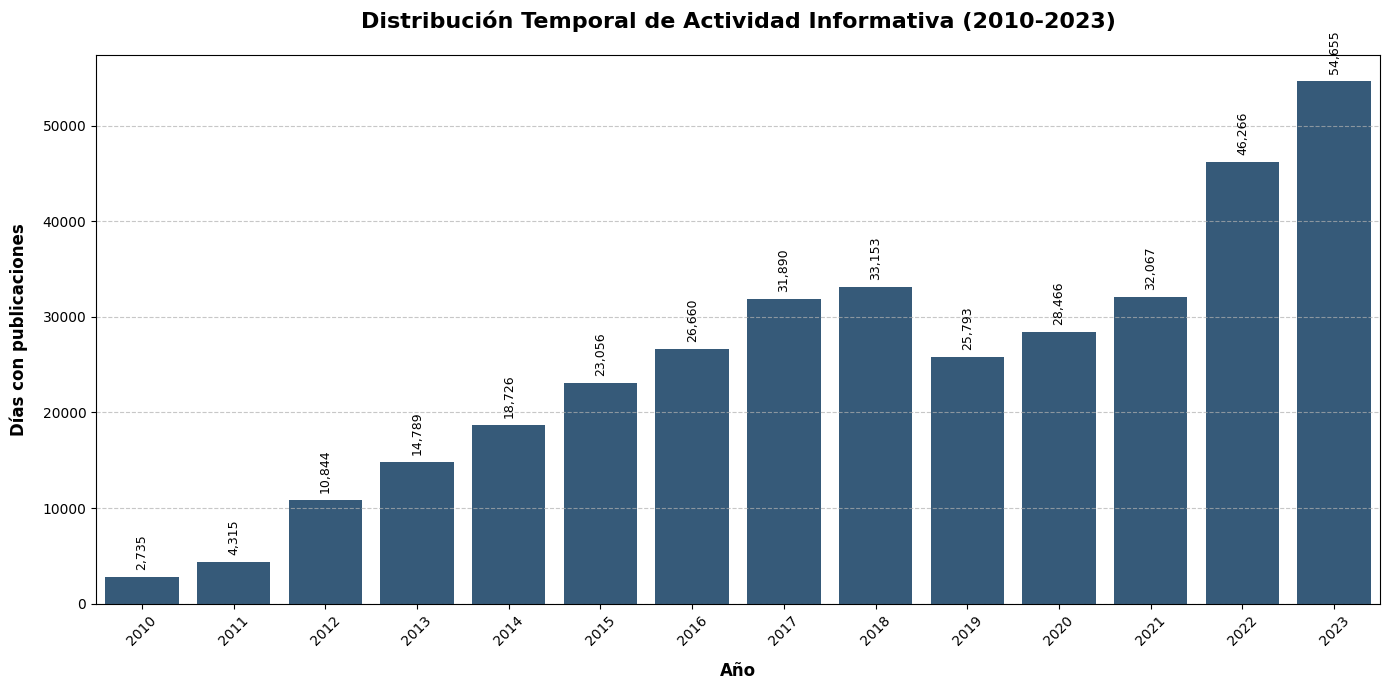

In [ ]:
grafica_noticias_por_ano()

Se observan menos noticias que en el dataset que hemos filtrado anteriormente para realizar la comparativa de titulares frente a noticias. Esta reducción se debe a la implementación de la media diaria, que fusiona todas las noticias de una mismo día mediante la media en una única entrada.